# scRNA-seq data analysis

Welcome to QIBS lab 1! In this lab, we will implement a standard scRNA-seq analysis pipeline, including

1. Data loading
2. Basic quality control
3. Data normalization and transformation
4. Feature selection
5. Dimensionality reduction
6. Cell typing

Our dataset for today is a PBMC scRNA-seq dataset from the 10X genomics platform: the data has already been processed from raw sequencing reads to filtered count matrices with the [10X CellRanger pipeline](https://www.10xgenomics.com/support/software/cell-ranger/latest) - additional data cleaning will be required before delving into analysis, though.

In a real-life analysis, you will likely use [_anndata_](https://anndata.readthedocs.io/en/stable/) and [_scanpy_](https://scanpy.readthedocs.io/en/stable/) to perform the outlined steps in Python. However, here, we will also implement each step using common Python packages for scientific computing like _numpy_, _pandas_, or _scipy_. To specify which kind of package and corresponding data to work with, we use the following color-codings for the exercises:

<div style="padding: 10px; border-radius: 1px; width: 60%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px; width: 20%; display: inline-block; text-align: center; vertical-align: middle">
    <b>Not Scanpy-based</b>
  </div>
  <div style="width: 5%; display: inline-block"></div>
  <div style="background-color: rgb(134, 86, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px; width: 20%; display: inline-block; text-align: center; vertical-align: middle">
    <b>Scanpy-based</b>
  </div>
  <div style="width: 5%; display: inline-block"></div>
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px; width: 20%; display: inline-block; text-align: center; vertical-align: middle">
    <b>Both</b>
  </div>
</div>

Additionally, questions are color-coded green. Use the file _worksheet_1.xlsx_ to provide your answers and upload both the answer sheet and notebook to the Google Drive folder shared with you; name the files *worksheet_1_LASTNAME.xlsx* and *sc_basics_LASTNAME.ipynb*. **The deadline for submitting your answers is April 2 at 12pm ET**.

<div style="padding: 10px; border-radius: 1px; width: 60%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px; width: 20%; display: inline-block; text-align: center; vertical-align: middle">
    <b>Question</b>
  </div>
</div>

## Setup instructions

Copy the data relevant for this lab into the repositories data directory.

```bash
cp -r /athena/qibs_class/scratch/pfw4001/data/lab_1 /athena/qibs_class/scratch/CWID/qibs2026/data/
```

Let's begin!

## Library imports

In [99]:
import scanpy as sc

from qibs2026 import DATA_DIR  # noqa

## General settings

In [100]:
sc.settings.verbosity = 2
sc.set_figure_params(frameon=False, transparent=True)

## Constants

In [101]:
DATASET_ID = "lab_1"

## Function definitions

## 1. Data loading

The output of CellRanger is a directory containing a number of files with different levels of processing. In most cases, we will work with the filtered - based on basic cell filtering - outputs in the sub-directory _filtered_feature_bc_matrix_ (see [here](https://www.10xgenomics.com/support/software/cell-ranger/latest/algorithms-overview/cr-gex-algorithm) for more details on CellRanger's filtering).

The _filtered_feature_bc_matrix/_ sub-directory contains three files:
1. _features.tsv.gz_: a tab-delimited file with annotations for each gene in the data.
2. _barcodes.tsv.gz_: the cell barcodes.
3. _matrix.mtx.gz_: the data matrix, where columns (rows) correspond to the cells (genes) aligned with the other two files.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 1.1</b>
  </div>
  <ul>
    <li>Use <a href="https://pandas.pydata.org/">pandas</a> to read the cell information and save it in the variable <code>obs_data</code>, with column names <code>"cell_barcode"</code>; use the barcode column as index.</li>
    <li>Use <a href="https://pandas.pydata.org/">pandas</a> to read the gene information and save it in the variable <code>var_data</code>, with column names <code>"ensembl_id"</code>, <code>"hgnc_id"</code>, and <code>"type"</code>.</li>
    <li>Use <a href="https://scipy.org/">SciPy</a> to read the count data (varibale name <code>counts</code>) with cells as rows and genes as columns.</li>
  </ul>
</div>

In [102]:
# Implement your solution here
import pandas as pd

data_path = '/athena/qibs_class/scratch/jfm4002/qibs2026/data/lab_1/raw/'

obs_data = pd.read_csv(data_path + 'filtered_feature_bc_matrix/barcodes.tsv.gz', header = None, names = ['cell_barcode'], index_col = 0)
obs_data.head()

""
cell_barcode
AAACCCAAGGCACTCC-1
AAACCCACAACTCCCT-1
AAACCCAGTACGAGCA-1
AAACCCAGTTGTGCAT-1
AAACCCATCTTCGGAA-1


In [103]:
var_data = pd.read_csv(data_path + 'filtered_feature_bc_matrix/features.tsv.gz', header = None, names = ['ensembl_id', 'hgnc_id', 'type'], sep = '\t')

var_data.head()

print(var_data.shape)

(36601, 3)


In [104]:
import scipy as sp

counts = sp.io.mmread(data_path + 'filtered_feature_bc_matrix/matrix.mtx.gz').T # Tranpose to get cells as rows and genes as columns

counts

<COOrdinate sparse matrix of dtype 'int64'
	with 4243843 stored elements and shape (8000, 36601)>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(134, 86, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 1.2</b>
  </div>
  <p>Use <a href="https://scanpy.readthedocs.io/en/stable/">Scanpy</a> to read the count data and save it as a variable <code>adata</code>.</p>
</div>

In [105]:
# Implement your solution here
import scanpy as sc

adata = sc.read_10x_mtx(path=data_path + "filtered_feature_bc_matrix/") # Needs full path because it reads the var as well, not only the counts

adata

AnnData object with n_obs × n_vars = 8000 × 36601
    var: 'gene_ids', 'feature_types'

## 2. Data overview

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 2.1</b>
  </div>
  <ol type="a">
    <li>How many cells does the data include?</li>
    <li>What format is the count data saved as and why?</li>
  </ol>
</div>

In [106]:
# Implement your solution here (using `counts`)
print(f"There are {counts.shape[0]} cells and {counts.shape[1]} genes in the dataset from counts.")

There are 8000 cells and 36601 genes in the dataset from counts.


In [107]:
# Implement your solution here (using `adata`)
print(f"There are {adata.n_obs} cells and {adata.n_vars} genes in the dataset from adata.")

There are 8000 cells and 36601 genes in the dataset from adata.


In [108]:
type(counts)

scipy.sparse._coo.coo_matrix

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 2.1</b>
  </div>
  <ul>
    <li>Make sure the counts are saved as a CSR matrix.</li>
    <li>Confirm that the count data indeed consists of counts.</li>
  </ul>
</div>

In [109]:
# Implement your solution here (using `counts`)
counts = counts.tocsr() # Convert to Compressed Sparse Row format for efficient row slicing (cells)
print(f"After conversion, counts is of type {type(counts)} and has shape {counts.shape}.")

After conversion, counts is of type <class 'scipy.sparse._csr.csr_matrix'> and has shape (8000, 36601).


In [110]:
# Implement your solution here (using `adata`)
print(f"Type of adata.X: {type(adata.X)}, shape of adata.X: {adata.X.shape}")

# Convert adata to csr from csc for efficient row slicing (cells) -> More efficeint than by genes since most of our operations will be by row
adata.X = adata.X.tocsr()
print(f"After conversion, adata.X is of type {type(adata.X)} and has shape {adata.X.shape}.")

Type of adata.X: <class 'scipy.sparse._csc.csc_matrix'>, shape of adata.X: (8000, 36601)


After conversion, adata.X is of type <class 'scipy.sparse._csr.csr_matrix'> and has shape (8000, 36601).


In [111]:
# Confirm count data is actually counts
print(f"Data type of counts: {counts.dtype}, data type of adata.X: {adata.X.dtype}")
print(counts[:5, :5].toarray())  # Print the first 5x5 block of counts to confirm they are floats
print(adata.X.todense()[:5, :5])  # Print the first 5x5 block of adata.X to confirm they are floats

Data type of counts: int64, data type of adata.X: float32
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]


[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 2.2</b>
  </div>
  Extract duplicate gene names from <code>var_data</code>.
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 2.2</b>
  </div>
  <p>How many gene names are duplicated?</p>
</div>

In [112]:
# Implement your solution here
n_duplicated_var = (var_data['hgnc_id'].value_counts() > 1).sum() # HUGO Gene Nomenclature Committee (HGNC) IDs are the standard gene symbols used in human genomics

print(f"There are {n_duplicated_var} duplicated HGNC IDs in the var data.")

print("The following are the duplicated HGNC IDs in the var data:")
print(var_data[var_data['hgnc_id'].duplicated()]['hgnc_id'])

There are 10 duplicated HGNC IDs in the var data.
The following are the duplicated HGNC IDs in the var data:
3237               TBCE
5950          LINC01238
6507           CYB561D2
10567             MATR3
16992         LINC01505
17693            HSPA14
25272           GOLGA8M
34716              GGT1
35970    ARMCX5-GPRASP2
36004           TMSB15B
Name: hgnc_id, dtype: object


In [113]:
var_data[var_data['hgnc_id'] == "TBCE"]

,ensembl_id,hgnc_id,type
3235,ENSG00000285053,TBCE,Gene Expression
3237,ENSG00000284770,TBCE,Gene Expression


<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(134, 86, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 2.3</b>
  </div>
  Does the AnnData object contain the same number of duplicated genes? If not, why?</li>
</div>

No, there is not the same amount of duplicated gene names in adata compaed to the var data object. Since the `var` in adata is structured as a `pandas.DataFrame`, it requires unique index entries and it uses the `HGNC IDs` as the default index for `var_names`. It creates new `HGNC IDs` by adding `-` and a number of each repeated `HGNC IDs` for each unique `ENSEMBL ID` starting with 1.

In [114]:
# Implement your solution here
n_duplicated_adata = (adata.var_names.value_counts() > 1).sum()

print(f"There are {n_duplicated_adata} duplicated HGNC IDs in the adata.var_names.")

There are 0 duplicated HGNC IDs in the adata.var_names.


<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 2.4</b>
  </div>
  Update the gene names in <code>var_data</code> to match <code>adata.var_names</code> and set the <code>hgnc_id</code> column as the index.
</div>

In [115]:
# Implement your solution here
var_data['hgnc_id'] = adata.var_names # Replace the hgnc_id column in var_data with the var_names from adata, which are the HGNC IDs which now adds the -1 to HGNCs that are duplicated for unique ENSEMBL IDs
var_data = var_data.set_index('hgnc_id') # Set the index to the HGNC IDs for easier lookup


In [116]:
adata.var[adata.var.gene_ids == 'ENSG00000284770'] # Showing how adata handles duplicated HGNC IDs by adding -1 to the second instance of TBCE

,gene_ids,feature_types
TBCE-1,ENSG00000284770,Gene Expression


## 3. Quality control

As a first step, we will apply a first crude filtering to retain
* cells expressing sufficiently many genes, and
* genes expressed in sufficiently many cells.

Cells expressing only few genes suggest these cells are impaired or not properly sequenced, and, vice-versa, if only few cells express a given gene, we cannot ensure statistical power for that gene.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.1</b>
  </div>
  Remove cells expressing less than 100 transcripts.
</div>

In [117]:
# Implement your solution here (cell filter)
transcripts_per_cell = counts.sum(axis=1).A1 # Sum the counts across all genes for each cell to get the total number of transcripts per cell, A1 converts to 1D array and A converts to array
counts = counts[~(transcripts_per_cell < 100),:] # Filter out cells with fewer than 100 transcripts
obs_data = obs_data[~(transcripts_per_cell < 100)] # Filter the obs_data to keep only the cells that passed the filter
print(f"After filtering, there are {counts.shape[0]} cells remaining.")

After filtering, there are 5155 cells remaining.


<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 3.1</b>
  </div>
  <ol type="a">
    <li>How many genes are not expressed?</li>
    <li>How many genes are expressed but in less than 10 cells?</li>
  </ol>
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.2</b>
  </div>
  Remove genes expressed in less than 10 cells.
</div>

In [118]:
# Implement your solution here (gene filter)
transcripts_per_gene = counts.sum(axis=0).A1 # Sum the counts across all cells for each gene to get the total number of transcripts per gene
not_expressed_genes = transcripts_per_gene == 0 # Identify genes that are not expressed in any cell

print(f"There are {not_expressed_genes.sum()} genes that are not expressed in any cell.")

There are 11775 genes that are not expressed in any cell.


In [119]:
cells_per_gene = (counts > 0).sum(axis=0).A1 # Count the number of cells in which each gene is expressed (non-zero count)
noisy_genes = cells_per_gene < 10 # Identify genes that are expressed in fewer than 10 cells
noisy_genes_but_expressed = (cells_per_gene[~not_expressed_genes] < 10) # Identify genes that are expressed but in less than 10 cells
print(f"There are {noisy_genes.sum()} genes that are expressed in fewer than 10 cells.")
print(f"There are {noisy_genes_but_expressed.sum()} genes that are expressed in fewer than 10 cells but have non-zero transcript counts.")

There are 21370 genes that are expressed in fewer than 10 cells.
There are 9595 genes that are expressed in fewer than 10 cells but have non-zero transcript counts.


In [97]:
counts = counts[:, ~(noisy_genes)] # Filter out genes that are expressed in fewer than 10 cells
var_data = var_data[~(noisy_genes)] # Filter the var_data to keep only the genes that passed the filter
print(f"After filtering, there are {counts.shape[1]} genes remaining.")

After filtering, there are 15231 genes remaining.


### Cell-specific quality control metrics

Following this first filtering, we can now compute quality control (QC) metrics to filter cells further - in a data-driven and statistically-grounded manner.

As a first step, we compute the number of transcripts captured across all genes for each cell - the library size - and the number of total unique genes per cell. Cells expressing many genes and exhibiting a large library size will reveal outlier cells; such measurements can represent doublets, i.e., different cells sequenced as a single cell, for example.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.3</b>
  </div>

  <ul>
    <li>Compute the library size and report its median.</li>
    <li>Compute the number of total unique genes captured in each cell, and report its median.</li>
    <li>Compute the log1p-transformation of each statistics.</li>
    <li>Add each statistic as a column to the <code>obs_data</code> DataFrame (names <code>"total_counts"</code>, <code>"log1p_total_counts"</code>, <code>"n_genes_by_counts"</code>, <code>"log1p_n_genes_by_counts"</code>).</li>
  </ul>
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 3.2</b>
  </div>
  <p>Why is a canonical log-transformation inadmissible for single-cell data?</p>
</div>

The median library size across all cells is: 985.0


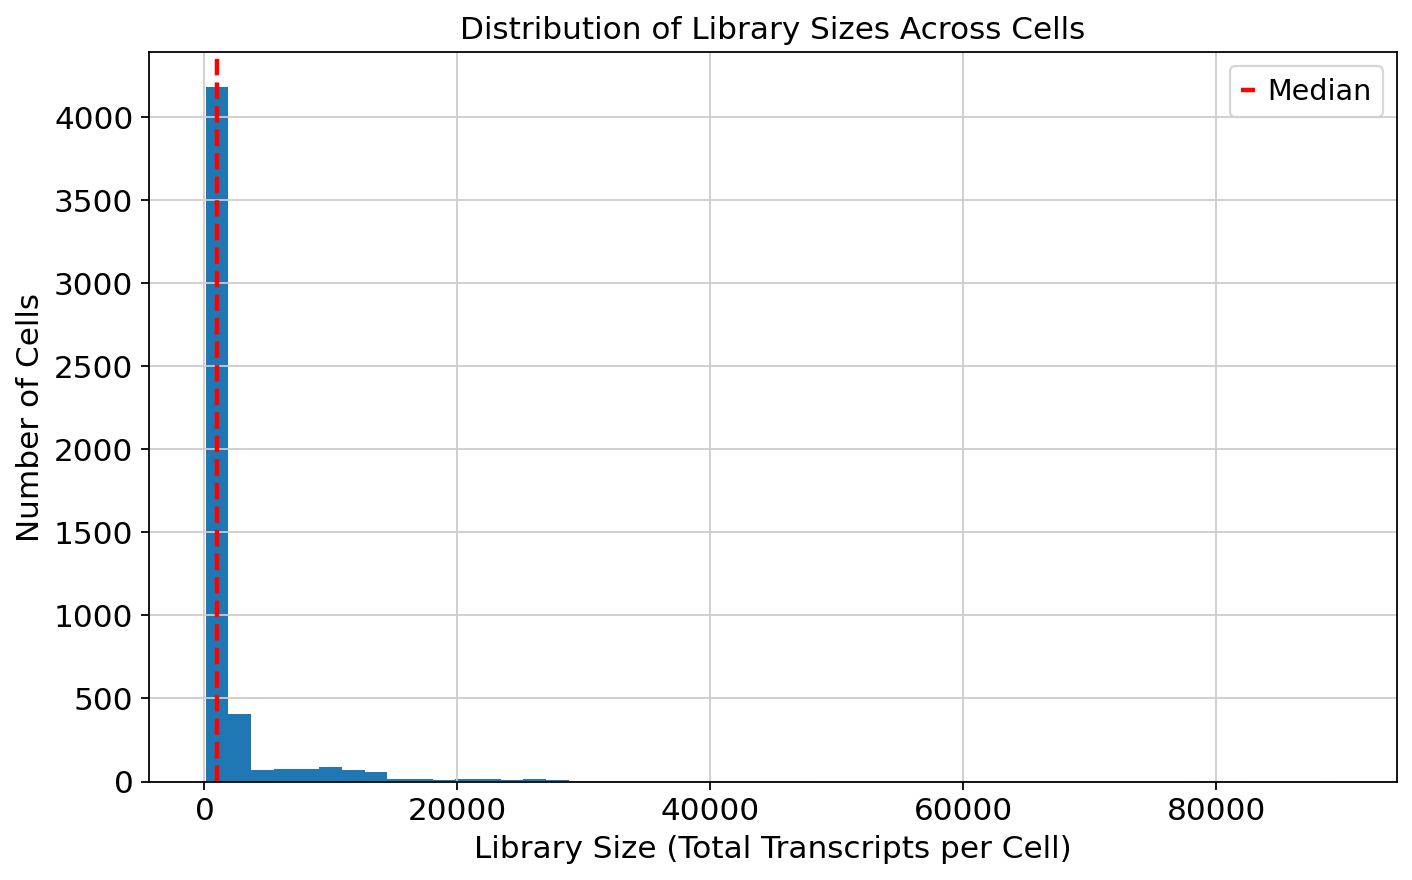

In [23]:
# Implement your solution here (library size)
import numpy as np
library_size = counts.sum(axis=1).A1 # Sum the counts across all genes for each cell to get the total number of transcripts per cell

print("The median library size across all cells is:", np.median(library_size))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(library_size, bins=50)
ax.axvline(np.median(library_size), color='red', linestyle='--', linewidth=2, label='Median') # Plot the median line
ax.set_xlabel('Library Size (Total Transcripts per Cell)')
ax.set_ylabel('Number of Cells')
ax.set_title('Distribution of Library Sizes Across Cells')
ax.legend() 
plt.show()

The median number of unique genes expressed per cell is: 546.0


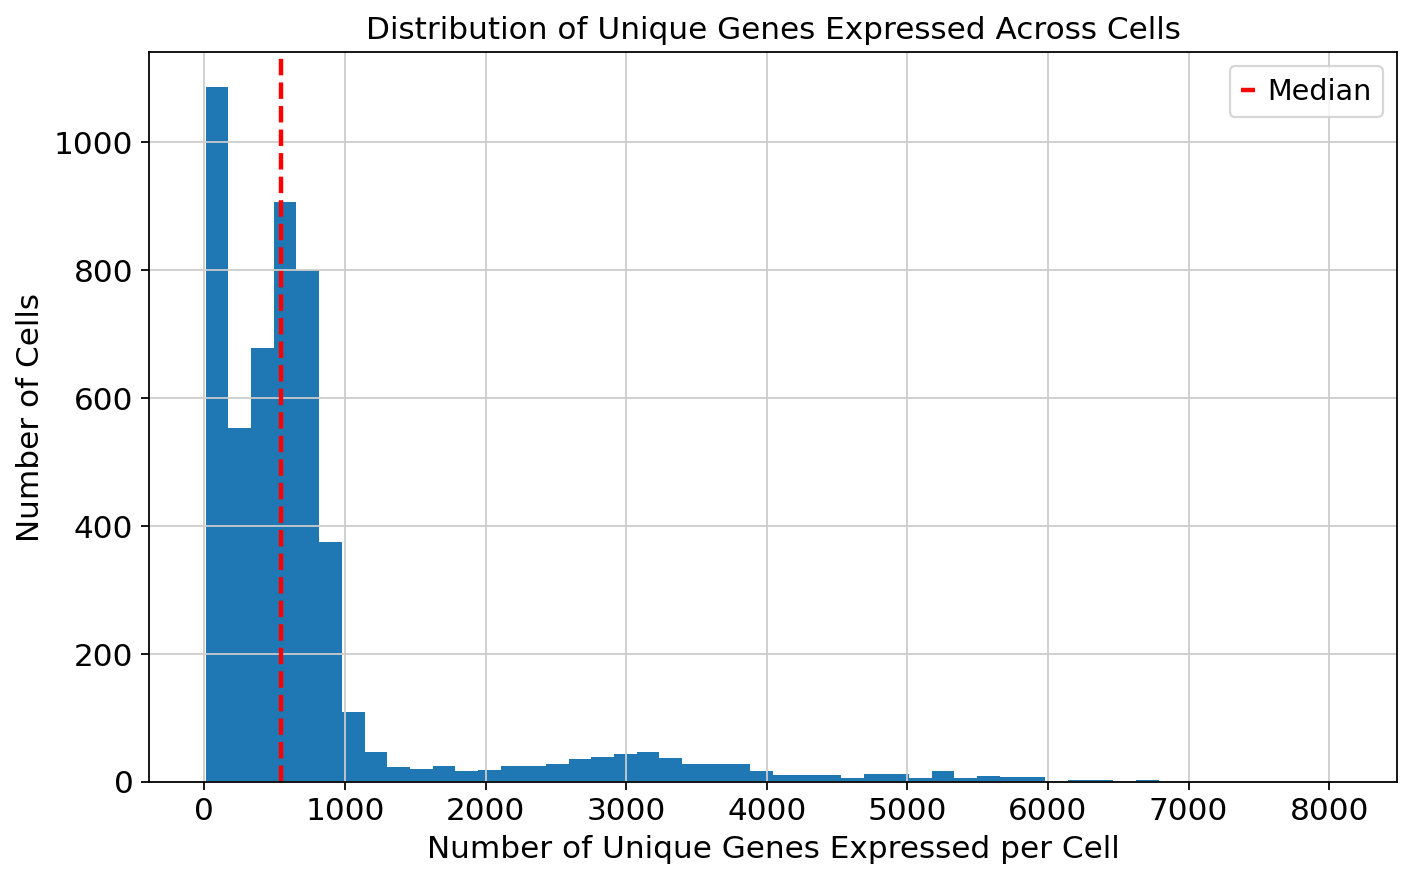

In [24]:
# Implement your solution here (number of genes per cell)
unique_genes_per_cell = (counts > 0).sum(axis=1).A1 # Count the number of unique genes expressed in each cell (non-zero count)
print("The median number of unique genes expressed per cell is:", np.median(unique_genes_per_cell))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(unique_genes_per_cell, bins=50)
ax.axvline(np.median(unique_genes_per_cell), color='red', linestyle='--', linewidth=2, label='Median') # Plot the median line
ax.set_xlabel('Number of Unique Genes Expressed per Cell')
ax.set_ylabel('Number of Cells')
ax.set_title('Distribution of Unique Genes Expressed Across Cells')
ax.legend()
plt.show()

The median log1p library size across all cells is: 6.893656354602635
The median log1p unique genes per cell across all cells is: 6.304448802421981


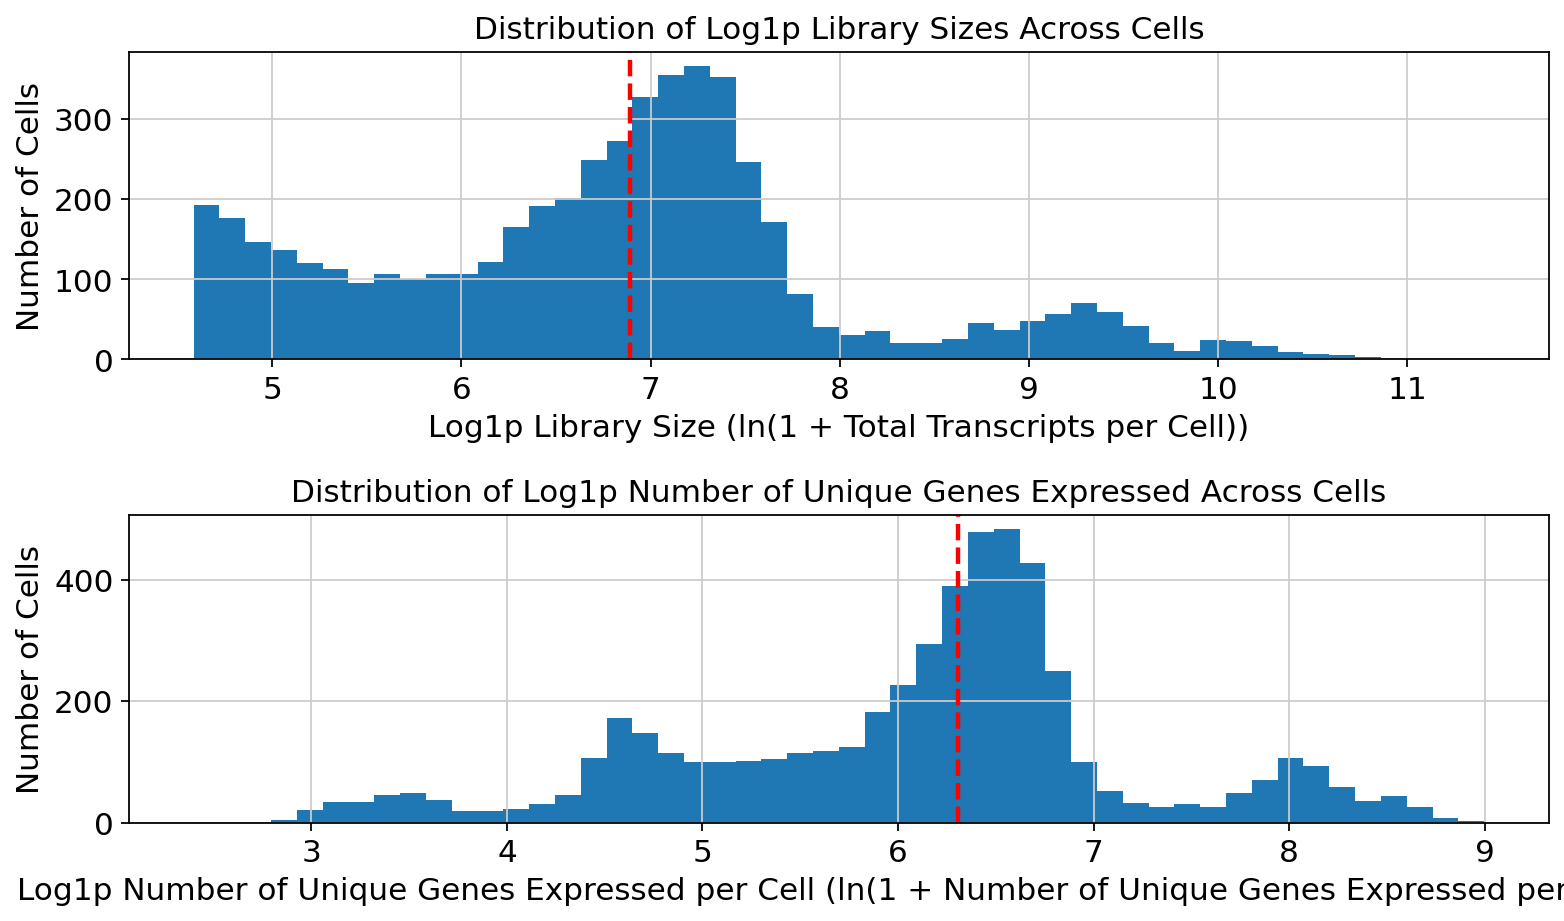

In [25]:
# Compute log1p (ln(1 + x)) transformation of each of the statistics
log1p_library_size = np.log1p(library_size)
log1p_unique_genes_per_cell = np.log1p(unique_genes_per_cell)

median_log1p_library_size = np.median(log1p_library_size)
median_log1p_unique_genes_per_cell = np.median(log1p_unique_genes_per_cell)

print("The median log1p library size across all cells is:", median_log1p_library_size)
print("The median log1p unique genes per cell across all cells is:", median_log1p_unique_genes_per_cell)

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 6))
ax[0].hist(log1p_library_size, bins=50)
ax[0].axvline(median_log1p_library_size, color='red', linestyle='--', linewidth=2, label='Median') # Plot the median line
ax[0].set_xlabel('Log1p Library Size (ln(1 + Total Transcripts per Cell))')
ax[0].set_ylabel('Number of Cells')
ax[0].set_title('Distribution of Log1p Library Sizes Across Cells') 
ax[1].hist(log1p_unique_genes_per_cell, bins=50)
ax[1].axvline(median_log1p_unique_genes_per_cell, color='red', linestyle='--', linewidth=2, label='Median') # Plot the median line
ax[1].set_xlabel('Log1p Number of Unique Genes Expressed per Cell (ln(1 + Number of Unique Genes Expressed per Cell))')
ax[1].set_ylabel('Number of Cells')
ax[1].set_title('Distribution of Log1p Number of Unique Genes Expressed Across Cells')
plt.tight_layout()
plt.show()


In [26]:
# Adding log1p statistics to obs_data for later use

obs_data["total_counts"] = library_size
obs_data["log1p_total_counts"] = log1p_library_size
obs_data["n_genes_by_counts"] = unique_genes_per_cell
obs_data["log1p_n_genes_by_counts"] = log1p_unique_genes_per_cell

obs_data.head()

,total_counts,log1p_total_counts,n_genes_by_counts,log1p_n_genes_by_counts
cell_barcode,,,,
AAACCCAGTTGTGCAT-1,874,6.774224,525,6.265301
AAACGAAAGAACTTCC-1,339,5.828946,46,3.850148
AAACGAACAATTGCGT-1,1660,7.415175,837,6.731018
AAACGAACACCGGAAA-1,124,4.828314,105,4.663439
AAACGAACAGATTTCG-1,132,4.890349,116,4.762174


Additional important QC metrics are the total fraction of the transcripts that are ribosomal RNAs or that attributed to the mitochondrial genome: mitochondrial fraction has been show to increase in dead or dying cells [(Azizi et al. 2018)](https://pubmed.ncbi.nlm.nih.gov/29961579/); high fractions of ribosomal RNA entail less coverage of the for us relevant mRNA.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.4</b>
  </div>

  <ul>
    <li>For each cell, compute the total and log1p-transformed total counts and percentage of counts originating from mitochondrial and ribosomal genes, respectively.</li>
    <li>Add each statistic as a column to the <code>obs_data</code> DataFrame (names <code>"total_counts_"</code>, <code>"log1p_total_counts_"</code>, <code>"pct_counts_"</code> with suffixes <code>"mito"</code> and <code>"ribo"</code>).</li>
  </ul>
</div>

In [27]:
# Implement your solution here (mitochondrial genes)
mito_genes = var_data.index.str.contains("^MT-") # Mitochondrial genes in human are typically prefixed with "MT-"
mito_counts_per_cell = counts[:, mito_genes].sum(axis=1).A1 # Sum the counts for mitochondrial genes for each cell
log1p_mito_counts_per_cell = np.log1p(mito_counts_per_cell) # Compute log1p transformation of mitochondrial counts per cell
pct_counts_mito_per_cell = mito_counts_per_cell / library_size * 100 # Compute percentage of mitochondrial counts per cell

print("The median mitochondrial counts per cell is:", np.median(mito_counts_per_cell))
print("The median percentage of mitochondrial counts per cell is:", np.median(pct_counts_mito_per_cell))

The median mitochondrial counts per cell is: 13.0
The median percentage of mitochondrial counts per cell is: 1.675977653631285


In [28]:
# Implement your solution here (ribosomal genes)
ribo_genes = var_data.index.str.contains("^RPS|^RPL|^MRP|^FAU$") # Ribosomal genes in human typically start with RPS (ribosomal protein small subunit), RPL (ribosomal protein large subunit), MRP (mitochondrial ribosomal protein) or FAU (Finkel-Biskis-Reilly murine sarcoma virus ubiquitously expressed) which is a ribosomal protein that is also a fusion gene with the viral genome
ribo_counts_per_cell = counts[:, ribo_genes].sum(axis=1).A1 # Sum the counts for ribosomal genes for each cell
log1p_ribo_counts_per_cell = np.log1p(ribo_counts_per_cell) # Compute log1p transformation of ribosomal counts per cell
pct_counts_ribo_per_cell = ribo_counts_per_cell / library_size * 100 # Compute percentage of ribosomal counts per cell

print("The median ribosomal counts per cell is:", np.median(ribo_counts_per_cell))
print("The median percentage of ribosomal counts per cell is:", np.median(pct_counts_ribo_per_cell))

The median ribosomal counts per cell is: 5.0
The median percentage of ribosomal counts per cell is: 0.6024096385542169


In [29]:
# Adding each statistic as a column to obs_data for later use
obs_data["total_counts_mito"] = mito_counts_per_cell
obs_data["log1p_total_counts_mito"] = log1p_mito_counts_per_cell
obs_data["pct_counts_mito"] = pct_counts_mito_per_cell
obs_data["total_counts_ribo"] = ribo_counts_per_cell
obs_data["log1p_total_counts_ribo"] = log1p_ribo_counts_per_cell
obs_data["pct_counts_ribo"] = pct_counts_ribo_per_cell

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 3.3</b>
  </div>

  <ol type="a">
    <li>How many mitochondiral genes does the data include?</li>
    <li>What is the highest mitochondrial percentage (rounded to two decimals)? Report the corresponding cell barcode.</li>
    <li>How many ribosomal genes does the data include?</li>
    <li>What is the highest ribosomal percentage (rounded to two decimals)? Report the corresponding cell barcode.</li>
  </ol>
</div>

In [30]:
# Implement your solution here
n_mito_genes = mito_genes.sum()
print(f"There are {n_mito_genes} mitochondrial genes in the dataset.")

max_pct_counts_mito_per_cell = pct_counts_mito_per_cell.max()
idx_max_pct_counts_mito_per_cell = pct_counts_mito_per_cell.argmax()
print(f"The maximum percentage of mitochondrial counts per cell is: {max_pct_counts_mito_per_cell:.2f} and the cell barcode is {obs_data.index[idx_max_pct_counts_mito_per_cell]}")

n_ribo_genes = ribo_genes.sum()
print(f"There are {n_ribo_genes} ribosomal genes in the dataset.")

max_pct_counts_mito_per_cell = pct_counts_ribo_per_cell.max()
idx_max_pct_counts_mito_per_cell = pct_counts_ribo_per_cell.argmax()
print(f"The maximum percentage of ribosomal counts per cell is: {max_pct_counts_mito_per_cell:.2f} and the cell barcode is {obs_data.index[idx_max_pct_counts_mito_per_cell]}")

There are 13 mitochondrial genes in the dataset.
The maximum percentage of mitochondrial counts per cell is: 95.43 and the cell barcode is GTGAGGACATGAGAAT-1
There are 174 ribosomal genes in the dataset.
The maximum percentage of ribosomal counts per cell is: 66.82 and the cell barcode is GTAGAAAAGTGCTAGG-1


### Gene-specific quality control metrics

Equivalent to cell-specific QC metrics, we can compute gene-specific metrics.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.5</b>
  </div>
  <ul>
    <li>Add the number of cells expressing each gene as a column <code>n_cells_by_counts</code> to <code>var_data</code>.</li>
    <li>Add the mean gene expression and its log1p transformation as columns <code>mean_counts</code> and <code>log1p_mean_counts</code> to <code>var_data</code>.</li>
    <li>Add the percentage of cells not expressing each gene as a column <code>pct_dropout_by_counts</code> to <code>var_data</code>.</li>
    <li>Add the total gene expression and its log1p transformation as columns <code>total_counts</code> and <code>log1p_total_counts</code> to <code>var_data</code></li>
  </ul>
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 3.4</b>
  </div>

  Which gene has the highest mean expression?
</div>

In [31]:
# Implement your solution here (n_cells_by_counts)
n_cells_by_counts = (counts > 0).sum(axis=0).A1 # Count the number of cells in which each gene is expressed (non-zero count)
print("The median number of cells in which a gene is expressed is:", np.median(n_cells_by_counts))
var_data["n_cells_by_counts"] = n_cells_by_counts # Add the n_cells_by_counts as a column to var_data for later use
var_data.head()

The median number of cells in which a gene is expressed is: 107.0


,ensembl_id,type,n_cells_by_counts
hgnc_id,,,
AL627309.1,ENSG00000238009,Gene Expression,122
AL627309.5,ENSG00000241860,Gene Expression,245
LINC01409,ENSG00000237491,Gene Expression,74
LINC01128,ENSG00000228794,Gene Expression,38
FAM41C,ENSG00000230368,Gene Expression,29


In [32]:
# Implement your solution here (mean GEX)
mean_gex_per_gene = counts.mean(axis=0).A1 # Compute the mean gene expression for each gene across all cells
log1p_mean_gex_per_gene = np.log1p(mean_gex_per_gene) # Compute log1p transformation of mean gene expression per gene
print("The median mean gene expression across all genes is:", np.median(mean_gex_per_gene))
print("The median log1p mean gene expression across all genes is:", np.median(log1p_mean_gex_per_gene))
var_data['mean_counts'] = mean_gex_per_gene # Add the mean_gex_per_gene as a column to var_data for later use
var_data['log1p_mean_counts'] = log1p_mean_gex_per_gene # Add the log1p_mean_gex_per_gene as a column to var_data for later use
var_data.head()

The median mean gene expression across all genes is: 0.0281280310378274
The median log1p mean gene expression across all genes is: 0.027739703089152946


,ensembl_id,type,n_cells_by_counts,mean_counts,log1p_mean_counts
hgnc_id,,,,,
AL627309.1,ENSG00000238009,Gene Expression,122,0.025024,0.024716
AL627309.5,ENSG00000241860,Gene Expression,245,0.051794,0.050498
LINC01409,ENSG00000237491,Gene Expression,74,0.020369,0.020164
LINC01128,ENSG00000228794,Gene Expression,38,0.008923,0.008884
FAM41C,ENSG00000230368,Gene Expression,29,0.005820,0.005803


In [33]:
# Implement your solution here (dropout percentage)
pct_dropout_by_gene = (counts == 0).mean(axis=0).A1 * 100 # Compute the percentage of cells in which each gene is not expressed (zero count)
print("The median percentage of dropout across all genes is:", np.median(pct_dropout_by_gene))
var_data['pct_dropout_by_counts'] = pct_dropout_by_gene # Add the pct_dropout_by_gene as a column to var_data for later use
var_data.head()

/tmp/ipykernel_618338/760626809.py:2: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient. Try using != instead.
  pct_dropout_by_gene = (counts == 0).mean(axis=0).A1 * 100 # Compute the percentage of cells in which each gene is not expressed (zero count)


The median percentage of dropout across all genes is: 97.92434529584207


,ensembl_id,type,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts
hgnc_id,,,,,,
AL627309.1,ENSG00000238009,Gene Expression,122,0.025024,0.024716,97.633366
AL627309.5,ENSG00000241860,Gene Expression,245,0.051794,0.050498,95.247333
LINC01409,ENSG00000237491,Gene Expression,74,0.020369,0.020164,98.564500
LINC01128,ENSG00000228794,Gene Expression,38,0.008923,0.008884,99.262852
FAM41C,ENSG00000230368,Gene Expression,29,0.005820,0.005803,99.437439


In [34]:
# Implement your solution here (total counts)
total_counts_per_gene = counts.sum(axis=0).A1 # Sum the counts across all cells for each gene to get the total counts per gene
log1p_total_counts_per_gene = np.log1p(total_counts_per_gene) # Compute log1p transformation of total counts per gene
print("The median total counts across all genes is:", np.median(total_counts_per_gene))
print("The median log1p total counts across all genes is:", np.median(log1p_total_counts_per_gene))
var_data['total_counts'] = total_counts_per_gene # Add the total_counts_per_gene as a column to var_data for later
var_data['log1p_total_counts'] = log1p_total_counts_per_gene # Add the log1p_total_counts_per_gene as a column to var_data for later use
var_data.head()

The median total counts across all genes is: 145.0
The median log1p total counts across all genes is: 4.983606621708336


,ensembl_id,type,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
hgnc_id,,,,,,,,
AL627309.1,ENSG00000238009,Gene Expression,122,0.025024,0.024716,97.633366,129,4.867534
AL627309.5,ENSG00000241860,Gene Expression,245,0.051794,0.050498,95.247333,267,5.590987
LINC01409,ENSG00000237491,Gene Expression,74,0.020369,0.020164,98.564500,105,4.663439
LINC01128,ENSG00000228794,Gene Expression,38,0.008923,0.008884,99.262852,46,3.850148
FAM41C,ENSG00000230368,Gene Expression,29,0.005820,0.005803,99.437439,30,3.433987


In [35]:
# Gene with highest gene expression
var_data.sort_values(by='mean_counts', ascending=False).head()

,ensembl_id,type,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
hgnc_id,,,,,,,,
MALAT1,ENSG00000251562,Gene Expression,4792,59.939282,4.109878,7.041707,308987,12.641058
B2M,ENSG00000166710,Gene Expression,4302,24.120854,3.223698,16.547042,124343,11.730807
HBB,ENSG00000244734,Gene Expression,526,22.055092,3.137887,89.796314,113694,11.641275
NEAT1,ENSG00000245532,Gene Expression,4371,16.469447,2.860453,15.208535,84900,11.349241
S100A8,ENSG00000143546,Gene Expression,2640,15.428516,2.799019,48.787585,79534,11.283952


<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.6</b>
  </div>
  <ol>
    <li>Visualize the distribution of the log1p-transformed library sizes and number of genes per cell, and the percentage of mitochondrial and ribosomal counts.</li>
    <li>Plot the mitochondiral count percentage against the library size.</li>
    <li>Plot the number of genes per cell against the library size.</li>
  </ol>
</div>

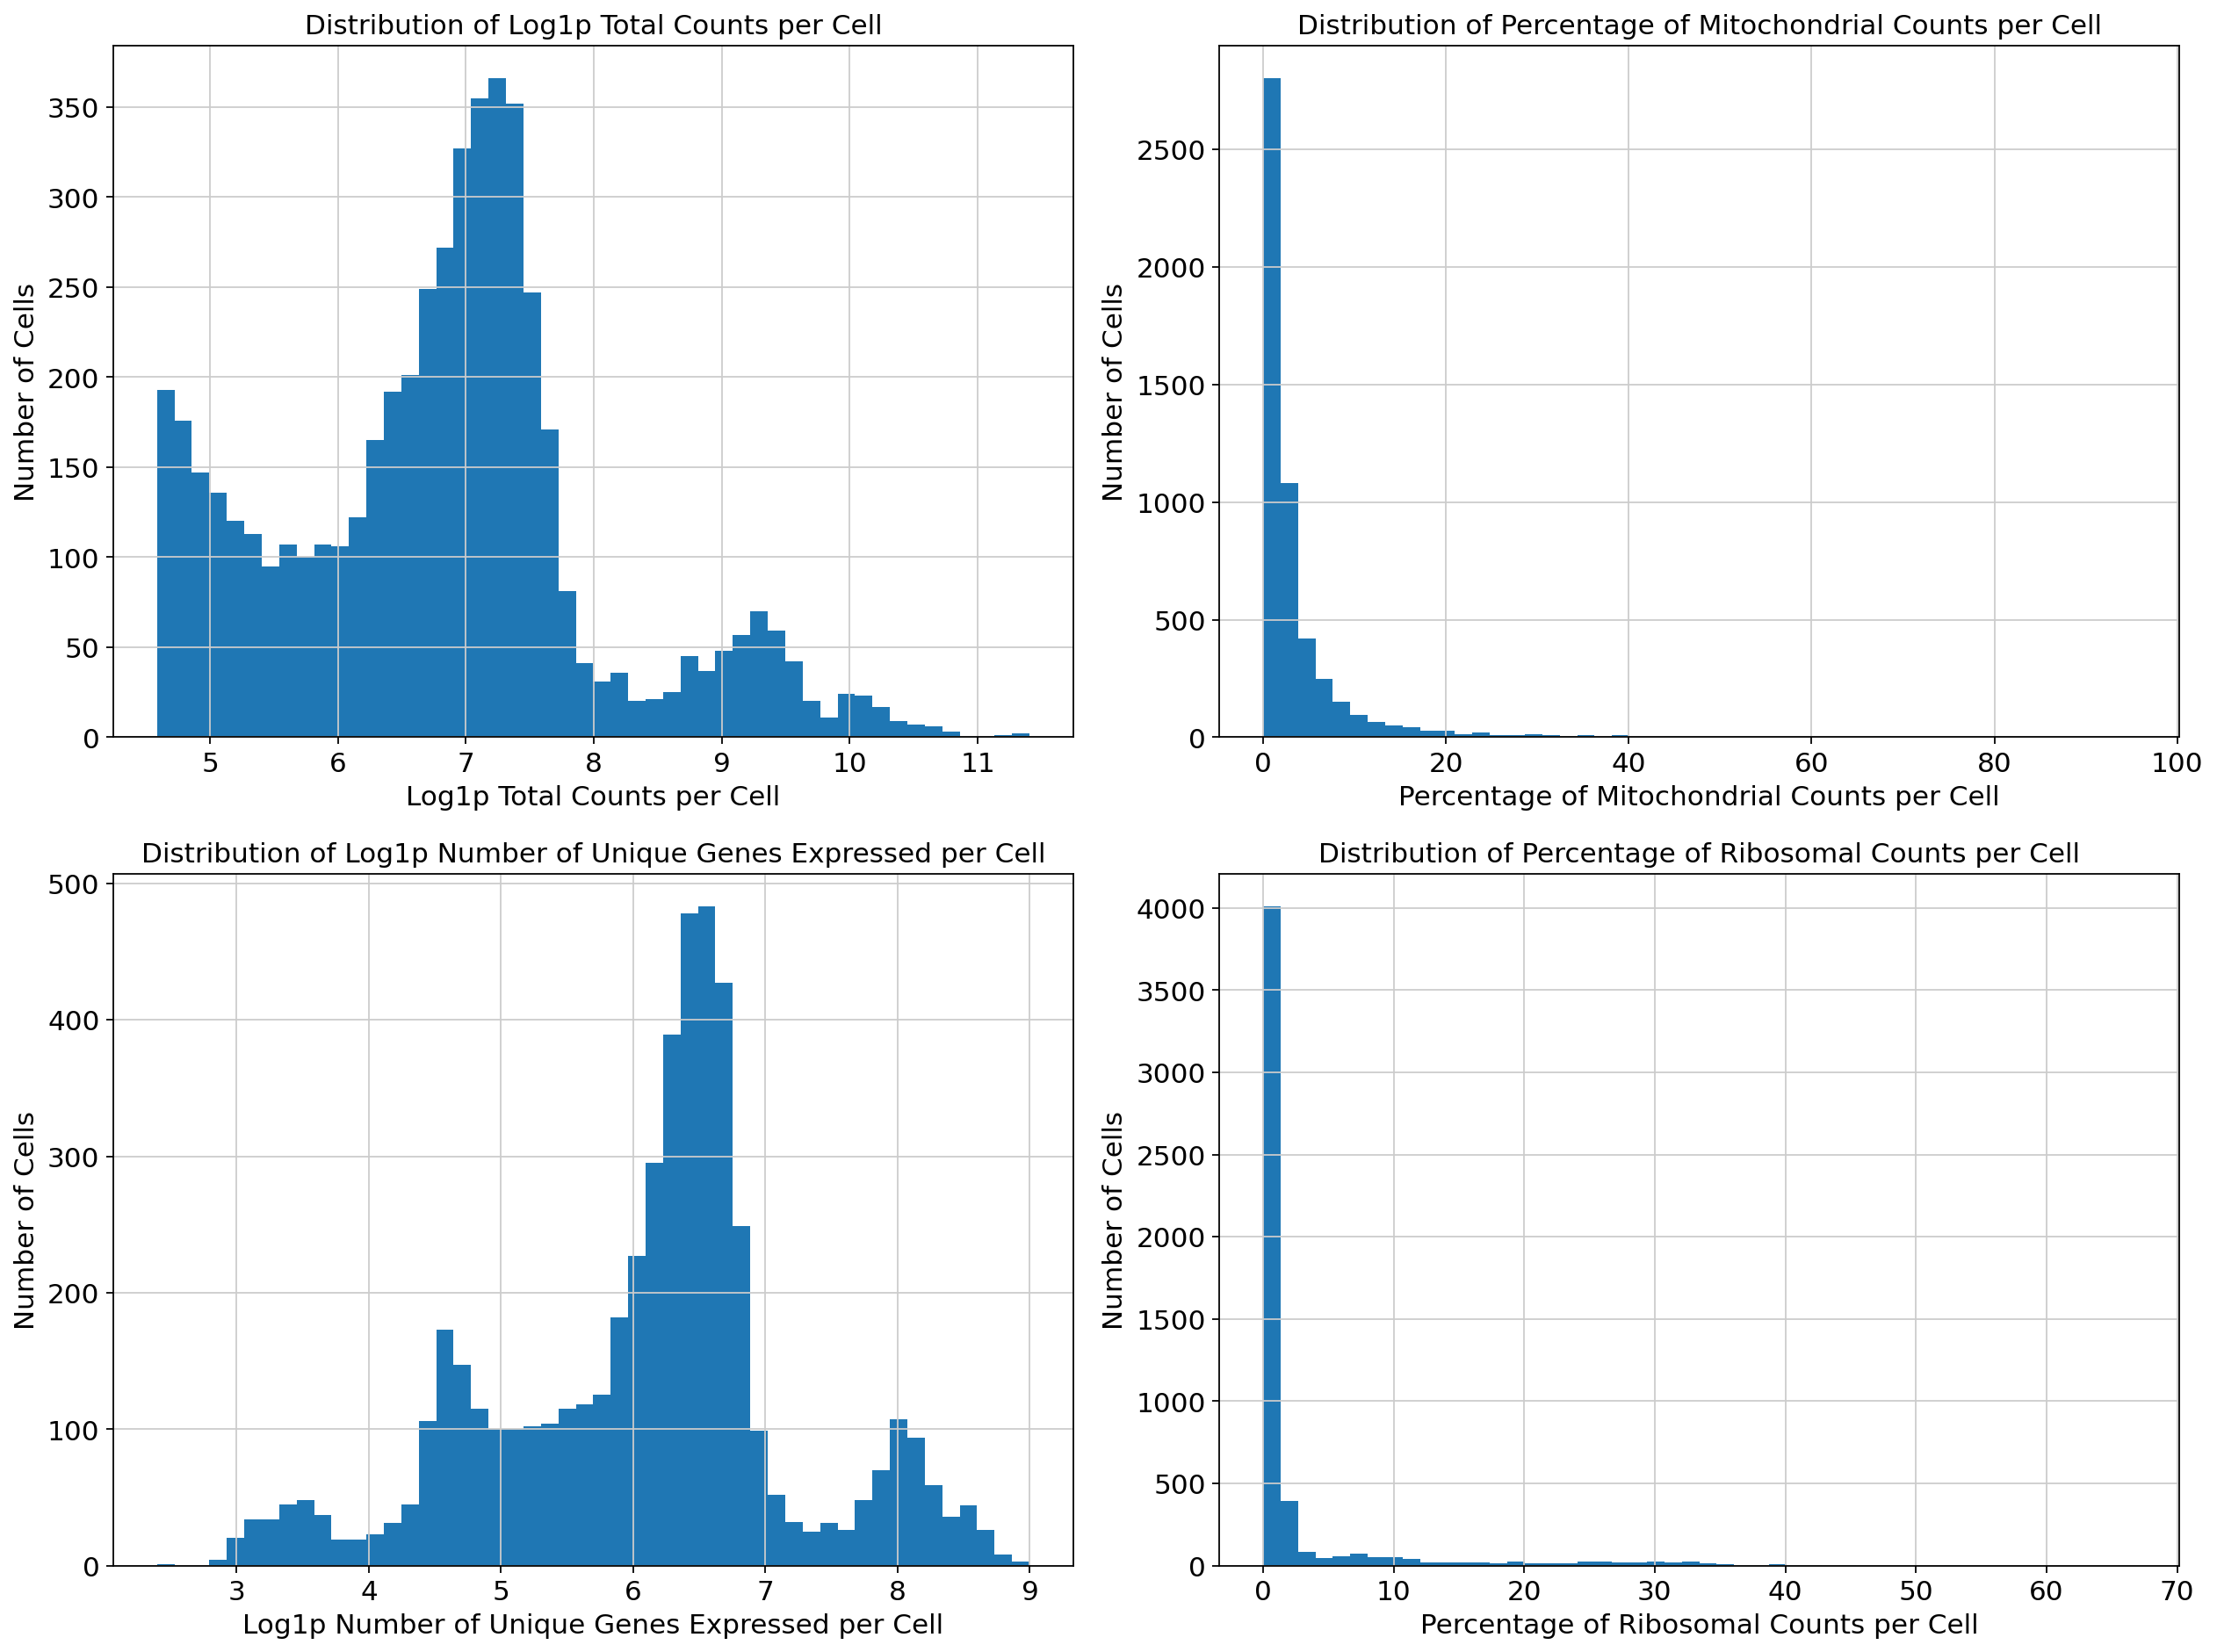

In [36]:
# Implement your solution here (single-QC plots)
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
ax[0, 0].hist(obs_data['log1p_total_counts'], bins=50)
ax[0, 0].set_xlabel('Log1p Total Counts per Cell')
ax[0, 0].set_ylabel('Number of Cells')
ax[0, 0].set_title('Distribution of Log1p Total Counts per Cell')
ax[1, 0].hist(obs_data['log1p_n_genes_by_counts'], bins=50)
ax[1, 0].set_xlabel('Log1p Number of Unique Genes Expressed per Cell')
ax[1, 0].set_ylabel('Number of Cells')
ax[1, 0].set_title('Distribution of Log1p Number of Unique Genes Expressed per Cell')
ax[0, 1].hist(obs_data['pct_counts_mito'], bins=50)
ax[0, 1].set_xlabel('Percentage of Mitochondrial Counts per Cell')
ax[0, 1].set_ylabel('Number of Cells')
ax[0, 1].set_title('Distribution of Percentage of Mitochondrial Counts per Cell')
ax[1, 1].hist(obs_data['pct_counts_ribo'], bins=50)
ax[1, 1].set_xlabel('Percentage of Ribosomal Counts per Cell')
ax[1, 1].set_ylabel('Number of Cells')
ax[1, 1].set_title('Distribution of Percentage of Ribosomal Counts per Cell')
plt.tight_layout()
plt.show()

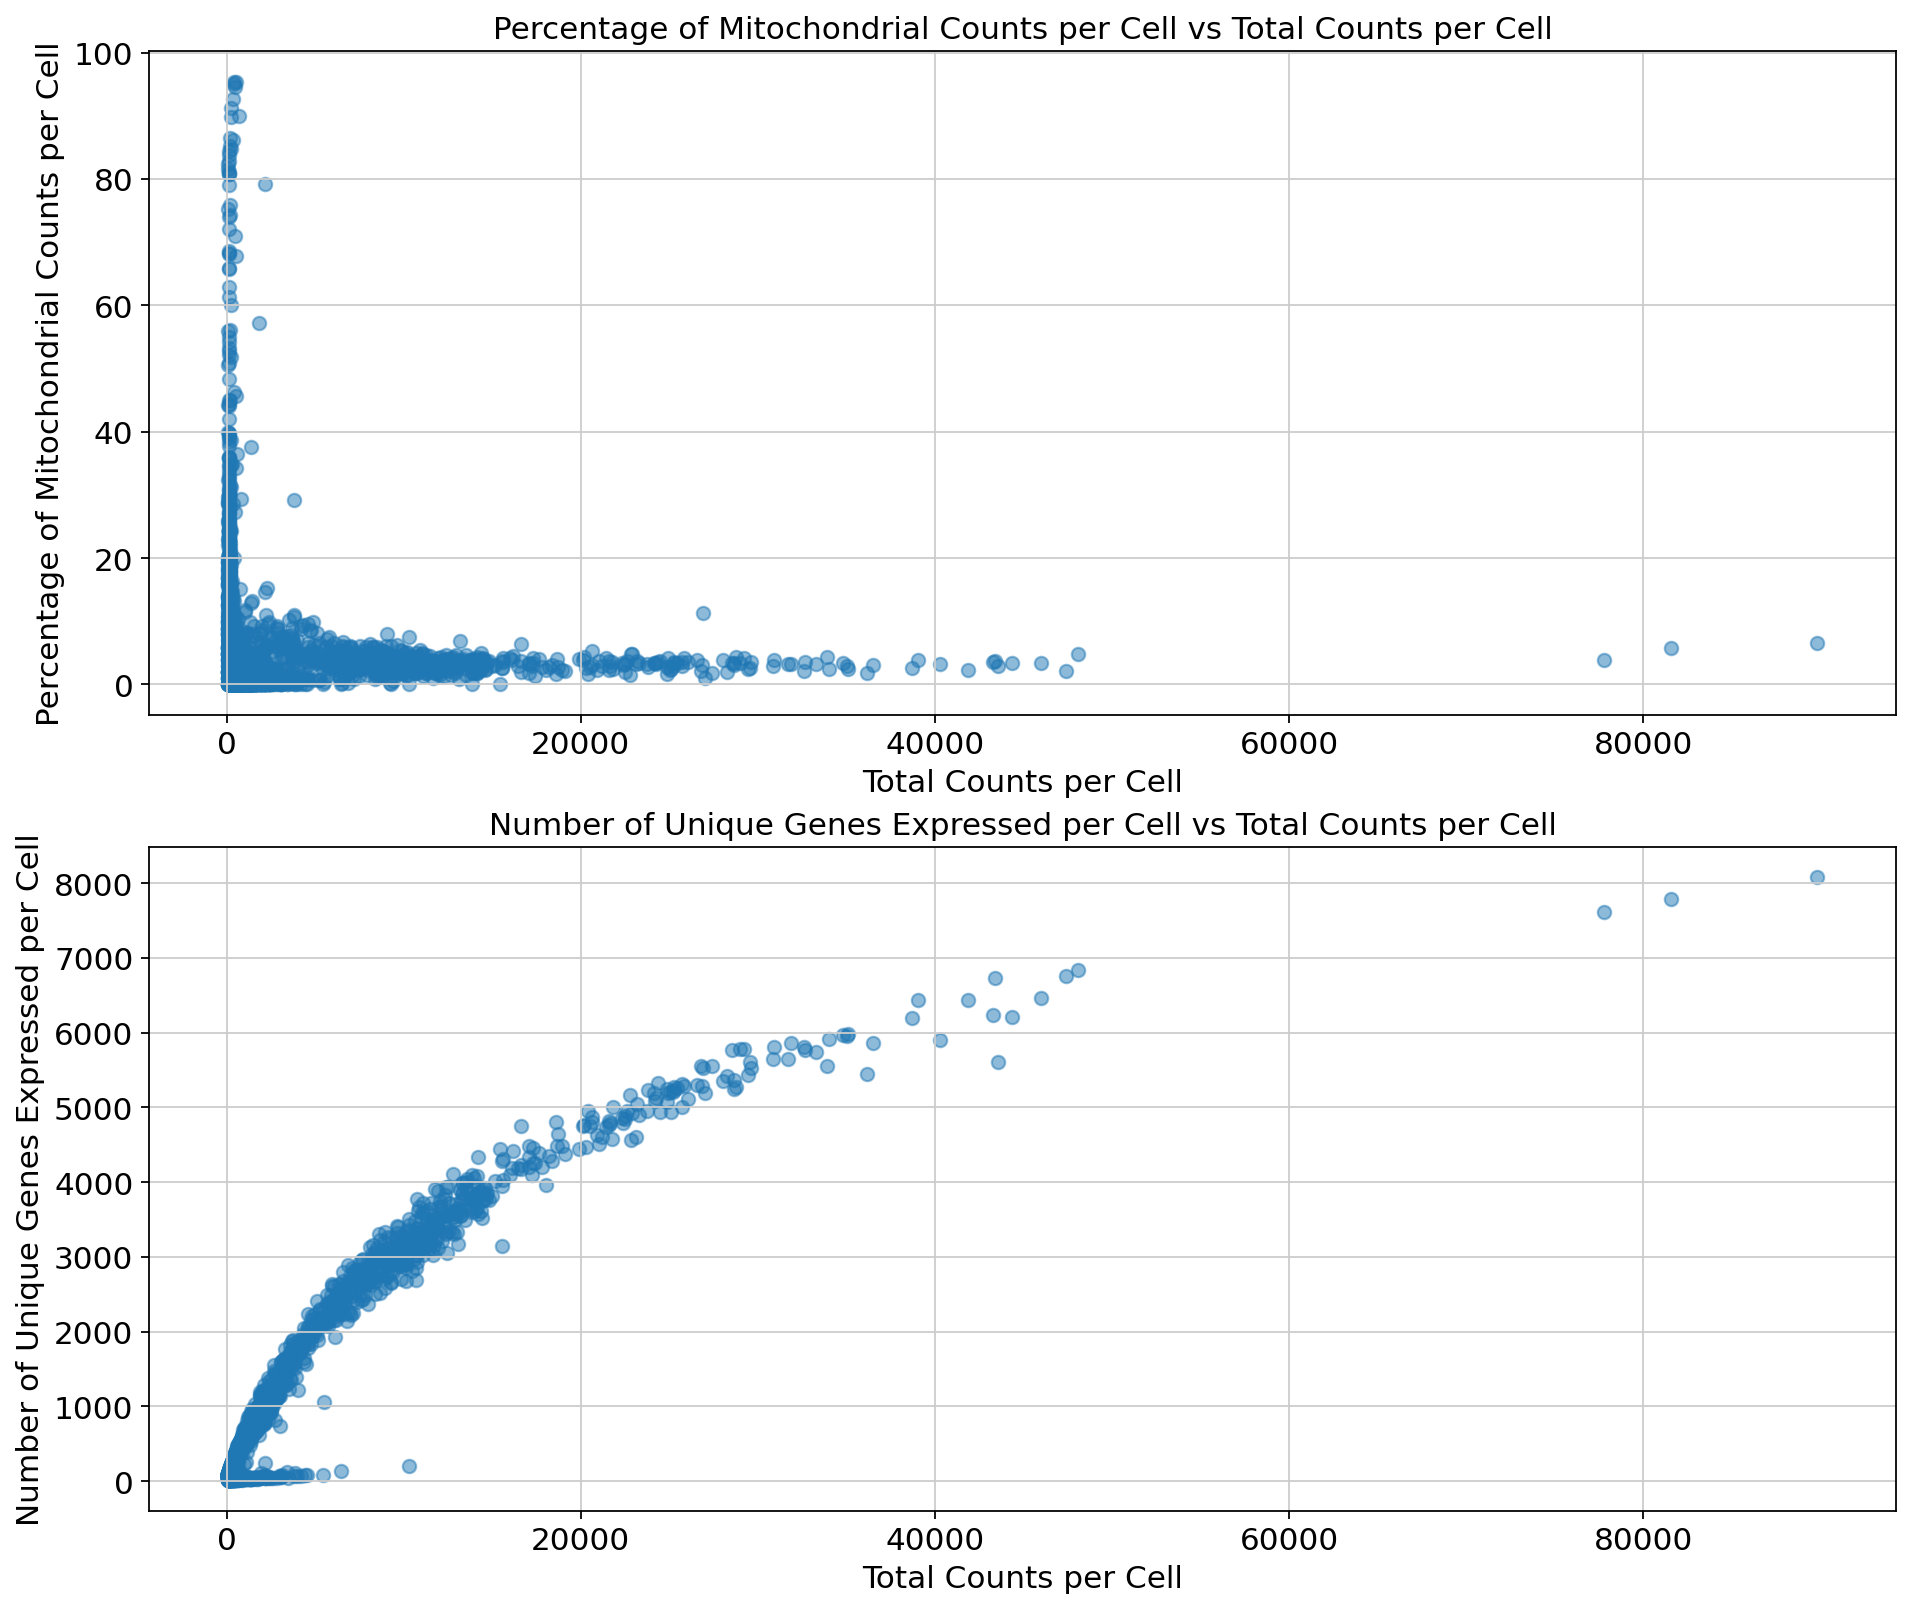

In [37]:
# Implement your solution here (QC metrics plotted against each other)
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(14, 12))
ax[0].scatter(obs_data['total_counts'], obs_data['pct_counts_mito'], alpha=0.5)
ax[0].set_xlabel('Total Counts per Cell')
ax[0].set_ylabel('Percentage of Mitochondrial Counts per Cell')
ax[0].set_title('Percentage of Mitochondrial Counts per Cell vs Total Counts per Cell')
ax[1].scatter(obs_data['total_counts'], obs_data['n_genes_by_counts'], alpha=0.5)
ax[1].set_xlabel('Total Counts per Cell')
ax[1].set_ylabel('Number of Unique Genes Expressed per Cell')
ax[1].set_title('Number of Unique Genes Expressed per Cell vs Total Counts per Cell')
plt.show()

We can use the plots visualizing the relationship between mitochondrial count percentage and number of genes per cell versus the total counts per cell, respectively, to identify outlier cells. Specifically, we are looking for cell with
1. high percentage of mitochondrial genes and low total counts &rarr; likely dying cells
2. high number of genes expressed and large library size &rarr; potentially doublets

Remember that high/low are always compared to the rest of the data! Our thresholds for filtering also depends on the system we are studying as we naturally expect stressed cells in a disease of inflammatory context, for example.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.7</b>
  </div>
  Remove cells expressing more than 60,000 transcripts or where mitochondrial genes account for at least 20 percent of the transcripts.
  </ol>
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 3.5</b>
  </div>

  What is the dimension of our dataset after filtering?
</div>

In [38]:
# Implement your solution here
print(f'Before filtering, there are {counts.shape[0]} / {obs_data.shape[0]} cells remaining, and {counts.shape[1]} / {var_data.shape[0]} genes.')
possible_doublet_cells = (obs_data['total_counts'] > 60000).values # Cells with total counts greater than 60,000 are likely to be doublets (two cells captured together instead of one)
high_mito_pct = (obs_data['pct_counts_mito'] >= 20).values # Cells with percentage of mitochondrial counts greater than 20% are likely to be low quality or dying cells
counts = counts[~(possible_doublet_cells | high_mito_pct), :] # Filter out cells that are likely to be doublets or low quality based on high mitochondrial percentage
obs_data = obs_data[~(possible_doublet_cells | high_mito_pct)] # Filter the obs_data to keep only the cells that passed the filter
print(f"After filtering, there are {counts.shape[0]} / {obs_data.shape[0]} cells remaining, and {counts.shape[1]} / {var_data.shape[0]} genes.")

Before filtering, there are 5155 / 5155 cells remaining, and 15231 / 15231 genes.
After filtering, there are 4990 / 4990 cells remaining, and 15231 / 15231 genes.


As a final step, we will perform the same analysis using Scanpy directly.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(134, 86, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.8</b>
  </div>
  Repeat the quality control steps using Scanpy, i.e.,
  <ol type="a">
    <li>Remove cells expressing less than 100 transcripts.</li>
    <li>Remove genes expressed in less than 10 cells.</li>
    <li>Update the AnnData object with the cell- and gene-specific metrics defined above but no additional metrics.</li>
    <li>Remove cells expressing more than 60,000 transcripts and where mitochondrial genes account for at least 20 percent of the transcripts.</li>
  </ol>
</div>

In [39]:
# Implement your solution here (Scanpy-based workflow)
sc.pp.filter_cells(adata, min_counts=100) # Filter out cells with fewer than 100 transcripts
sc.pp.filter_genes(adata, min_cells=10) # Filter out genes that are expressed in fewer than 10 cells
adata.var['mito'] = adata.var_names.str.contains("^MT-") # Annotate mitochondrial genes in adata.var
adata.var['ribo'] = adata.var_names.str.contains("^RPS|^RPL|^MRP|^FAU$") # Annotate ribosomal genes in adata.var
sc.pp.calculate_qc_metrics(adata, expr_type="counts", var_type="genes", qc_vars=['mito', 'ribo'], percent_top=None, log1p=True, inplace=True) # Calculate QC metrics for mitochondrial and ribosomal genes
sc.pp.filter_cells(adata, max_counts=60000) # Filter out cells with total counts greater than 60,000 which are likely to be doublets
adata = adata[adata.obs.pct_counts_mito < 20, :] # Filter out cells with percentage of mitochondrial counts greater than 20% which are likely to be low quality or dying cells
print(adata)
print(f"After filtering, there are {adata.n_obs} cells and {adata.n_vars} genes remaining in the adata object.")

filtered out 2845 cells that have less than 100 counts


filtered out 21370 genes that are detected in less than 10 cells
filtered out 3 cells that have more than 60000 counts
View of AnnData object with n_obs × n_vars = 4990 × 15231
    obs: 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mito', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
After filtering, there are 4990 cells and 15231 genes remaining in the adata object.


In [40]:
print(f"Checking concordance between counts and adata dimensionality after filtering: {counts.shape[0]} cells and {counts.shape[1]} genes in counts, {adata.n_obs} cells and {adata.n_vars} genes in adata.")

Checking concordance between counts and adata dimensionality after filtering: 4990 cells and 15231 genes in counts, 4990 cells and 15231 genes in adata.


In [41]:
obs_data.head()

,total_counts,log1p_total_counts,n_genes_by_counts,log1p_n_genes_by_counts,total_counts_mito,log1p_total_counts_mito,pct_counts_mito,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo
cell_barcode,,,,,,,,,,
AAACCCAGTTGTGCAT-1,874,6.774224,525,6.265301,8,2.197225,0.915332,2,1.098612,0.228833
AAACGAAAGAACTTCC-1,339,5.828946,46,3.850148,1,0.693147,0.294985,8,2.197225,2.359882
AAACGAACAATTGCGT-1,1660,7.415175,837,6.731018,18,2.944439,1.084337,8,2.197225,0.481928
AAACGAACACCGGAAA-1,124,4.828314,105,4.663439,17,2.890372,13.709677,1,0.693147,0.806452
AAACGAACAGATTTCG-1,132,4.890349,116,4.762174,7,2.079442,5.303030,0,0.000000,0.000000


In [42]:
var_data.head()

,ensembl_id,type,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
hgnc_id,,,,,,,,
AL627309.1,ENSG00000238009,Gene Expression,122,0.025024,0.024716,97.633366,129,4.867534
AL627309.5,ENSG00000241860,Gene Expression,245,0.051794,0.050498,95.247333,267,5.590987
LINC01409,ENSG00000237491,Gene Expression,74,0.020369,0.020164,98.564500,105,4.663439
LINC01128,ENSG00000228794,Gene Expression,38,0.008923,0.008884,99.262852,46,3.850148
FAM41C,ENSG00000230368,Gene Expression,29,0.005820,0.005803,99.437439,30,3.433987


## 4. Data preprocessing

### Count normalization and transformation

Following filtering cells and genes and equivalent to standard data analysis pipeline, it is now time to normalize our observations. Normalization ensures that all cells are comparable relative to each other - an aspect not automatically guaranteed since the capture rate can vary dramatically across cells and, thus, heavily confounding the count values in scRNA-seq experiments. For example, does a value of '2' transcripts mean the same thing in a cell which had 10,000 transcripts, vs. one that is 1,000 transcripts? Probably not!

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 4.1</b>
  </div>
  <ol type="a">
    <li>Normalize the cell size to the median library size, and save the resulting array as <code>normalized_counts</code> in CSR format.</li>
    <li>Log1p-transform the normalized counts, and save the resulting array as <code>log1p_normalized_counts</code>.</li>
  </ol>
</div>

In [43]:
# Implement your solution here (normalization)
median_library_size = np.median(obs_data['total_counts'])
normalized_counts_per_cell = (counts / obs_data['total_counts'].values[:, None]) * median_library_size # Normalize the counts for each cell by dividing by the total counts (library size) for that cell and multiplying by the median library size across all cells to bring the normalized counts back to a similar scale as the original counts
normalized_counts_per_cell = normalized_counts_per_cell.tocsr() # Convert to sparse format for efficient storage and computation

In [44]:
# Implement your solution here (log1p-transformation)
log1p_normalized_counts_per_cell = np.log1p(normalized_counts_per_cell) # Compute log1p transformation of the normalized counts per cell
log1p_normalized_counts_per_cell = log1p_normalized_counts_per_cell.tocsr() # Convert to sparse format for efficient storage and computation

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(134, 86, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 4.2</b>
  </div>
  <ol type="a">
    <li>Save the whole counts as a layer of <code>adata</code>, named <code>"counts"</code>.</li>
    <li>Normalize the data to the median library size.</li>
    <li>Log1p-transform the normalized data.</li>
  </ol>
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 4.1</b>
  </div>

  How can you keep track of whether or not your data is log1p-transformed in an AnnData-Scanpy-based workflow?
</div>

In [45]:
# Implement your solution here
adata.layers["counts"] = counts # Add the raw counts as a layer in adata
sc.pp.normalize_total(adata, target_sum=None) # By default the None in target_sum normalizes the total count per cell to the median of total counts for all cells before normalization
sc.pp.log1p(adata) # Compute log1p transformation of the normalized counts in adata.X and store the result back in adata.X

normalizing counts per cell


/tmp/ipykernel_618338/3011030241.py:2: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers["counts"] = counts # Add the raw counts as a layer in adata


    finished (0:00:05)


In [46]:
adata

AnnData object with n_obs × n_vars = 4990 × 15231
    obs: 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mito', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'log1p'
    layers: 'counts'

We will not z-score our data here, but it is an optional step to be aware of: in some cases, we want to scale each gene to zero mean and a standard deviation of 1. Such a transformation can also dramatically change the structure of your data.

The guiding principle here: there are many subjective choices in single-cell analysis, each of which can have major consequences on your embeddings, visualizations, differential expression, etc. It is a good idea to play around with your data with multiple iterations of processing before finalizing an analysis. Always think about your specific biological system and question, and how you might justify each choice you make.

### Feature selection

As a next step, we will identify genes we even want to consider or focuse on in our analysis (beyond those we filtered earlier for technical reasons). Intuitvely, we want to focus on genes varying across our observations as they contain non-redundant information; similarly, housekeeping genes are ubiquitously expressed and do not carry much information on biological heterogeneity. Highly-variable gene (HVG) selection accomplishes this goal by first defining a measure of how variable each gene is across cells in our dataset; thresholding defines HVGs; subsequent downstream analyses will operate on these HVGs to generate embeddings and visualizations of cells.

**Important:** unlike poorly-captured genes we filtered earlier, we do not actually want *remove* lowly-variable genes from your dataset entirely as some genes may be differential across conditions, cell types, etc. even when they are not statistically highly-variable. No method for detection of highly-variable genes is perfect, so the goal is to use HVGs for generating your embeddings/visualizations, but retaining all genes for future analysis.

At first thought, you might consider simply computing the empirical variance of each gene across cells as a measure of variability. However, the variance strongly correlates with mean expression, i.e., filtering based on variance is nearly equivalent to picking the most highly expressed genes overall! In reality, sometimes genes with a low mean expression are going to be the most important, such as those expressed highly in a rare population of cells.

To consider the scaling of the variance with the mean, the method developed by [Smillie et al. method](https://pubmed.ncbi.nlm.nih.gov/31348891/) attempts to find genes whose variance is higher than expected, given the mean expression of that gene. This is accomplished by first fitting a simple model where *dispersion* (the variance standardized by the mean) is a function of the mean, and the *residuals* (true dispersion - predicted dispersion) are a measure of variability. We will implement this method here, but Scanpy provides more robust and sophisticated HVG identification routines.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 4.3</b>
  </div>
  <ol type="a">
    <li>For each gene, compute the mean and standard deviation of its log1p-normalized expression.</li>
    <li>Compute the dispersion. To avoid dividing by zero, set zero mean values to 1 x 10-12</li>
    <li>Using statsmodels, fit a locally weighted scatterplot smoothing function to the log-dispersion and log-mean.</li>
    <li>Compute the residuals under the fitted model, and plot both the data, colored based on these residuals, and fitted curve.</li>
  </ol>
</div>

In [47]:
# Implement your solution here (mean, standard deviation, and dispersion)
mean_log1p_normalized_gex = log1p_normalized_counts_per_cell.mean(axis=0).A1 # Compute the mean of the log1p normalized counts for each gene across all 
var_log1p_normalized_gex = (log1p_normalized_counts_per_cell.power(2)).mean(axis=0) - (log1p_normalized_counts_per_cell.mean(axis=0).A1 * log1p_normalized_counts_per_cell.mean(axis=0).A1) # Compute the variance of the log1p normalized counts for each gene across all cells using the formula Var(X) = E[X^2] - (E[X])^2
std_log1p_normalized_gex = np.sqrt(var_log1p_normalized_gex) # Compute the standard deviation of the log1p normalized counts for each gene across
corrected_mean_log1p_normalized_gex = mean_log1p_normalized_gex.copy() # Create a copy of the mean_log1p_normalized_gex to correct for any mean values that are exactly 0
corrected_mean_log1p_normalized_gex[mean_log1p_normalized_gex == 0] = 1e-12 # Replace any mean values that are exactly 0 with a small value to avoid division by zero when computing dispersion
disp_log1p_normalized_gex = (var_log1p_normalized_gex / corrected_mean_log1p_normalized_gex).A1 # Compute the dispersion of the log1p normalized counts for each gene across all cells using the formula Dispersion = Variance / Mean (also called Variance-to-Mean Ratio)

In [48]:
# Implement your solution here (model fit and residual computation)
import statsmodels.api as sm

# Creating Locally Weighted Scatterplot Smoothing (LOWESS) model to fit the relationship between mean and dispersion of log1p normalized gene expression across all genes
lowess_fit = sm.nonparametric.lowess(disp_log1p_normalized_gex, corrected_mean_log1p_normalized_gex, return_sorted=False)
lowess_residuals = disp_log1p_normalized_gex - lowess_fit # Compute the residuals from the LOWESS fit to identify highly variable genes as those with high positive residuals (dispersion higher than expected given their mean expression)

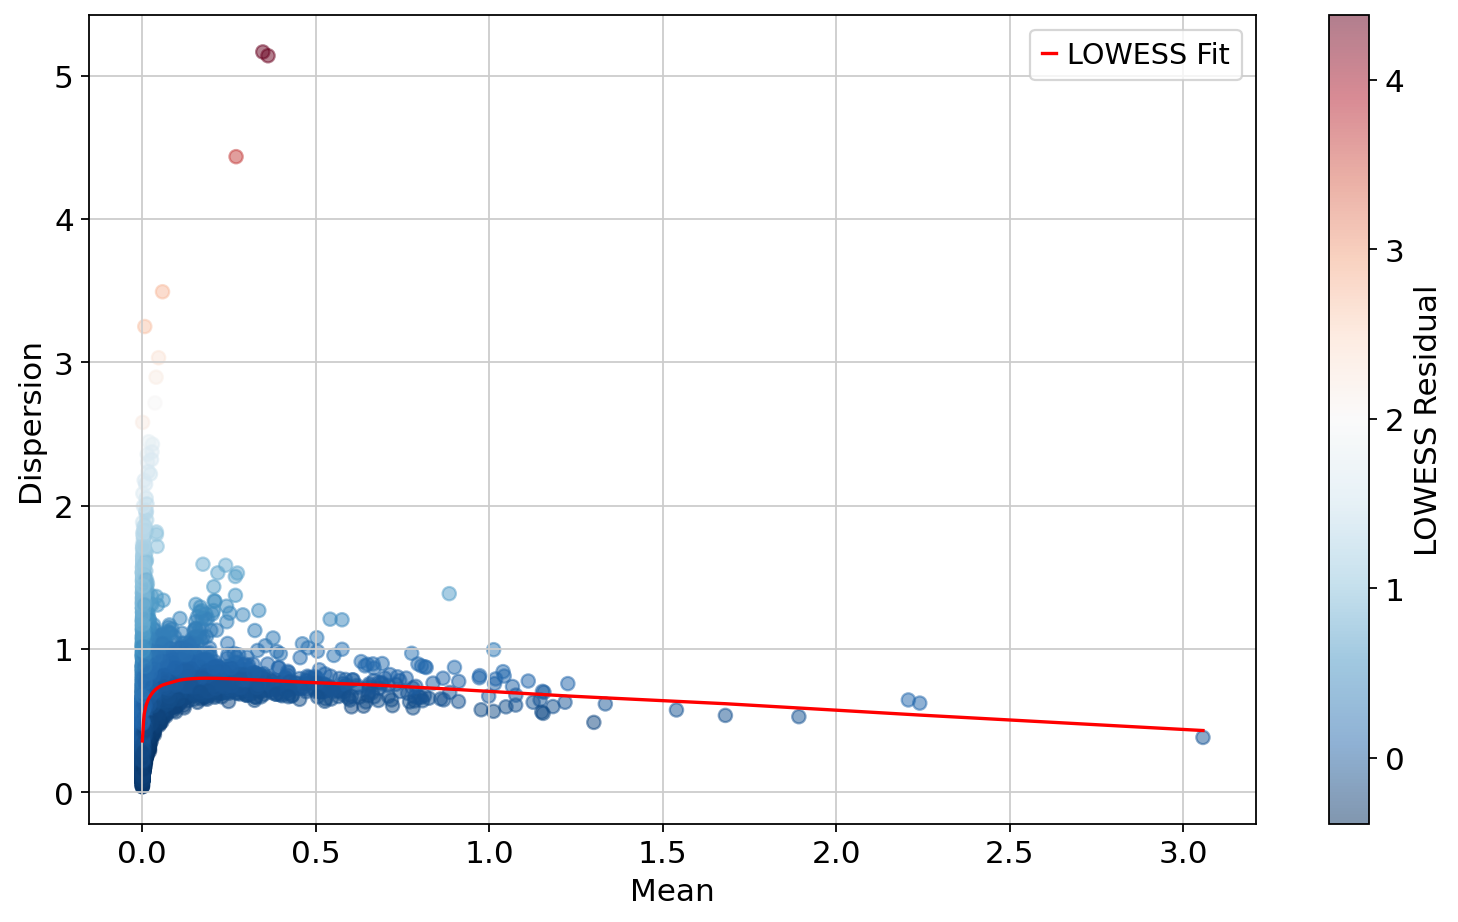

In [49]:
# Implement your solution here (plotting)
sorted_idx = np.argsort(corrected_mean_log1p_normalized_gex)
sorted_mean = corrected_mean_log1p_normalized_gex[sorted_idx]
sorted_lowess = lowess_fit[sorted_idx]

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(corrected_mean_log1p_normalized_gex, disp_log1p_normalized_gex, c=lowess_residuals, cmap='RdBu_r', alpha=0.5)
ax.plot(sorted_mean, sorted_lowess, color='red', label='LOWESS Fit')
plt.colorbar(scatter, ax=ax, label='LOWESS Residual')
ax.set_xlabel('Mean')
ax.set_ylabel('Dispersion')
ax.legend()
plt.tight_layout()
plt.show()

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 4.4</b>
  </div>
  Extract the 1000 most highly variable genes.
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 4.2</b>
  </div>

  What are the 5 most highly variable genes?
</div>

In [50]:
# Implement your solution here (plotting)
lowess_residuals_sorted_idx = np.argsort(lowess_residuals)[::-1] # Get the indices that would sort the LOWESS residuals in descending order to identify the genes with the highest positive residuals (most highly variable genes)
top_1000_hvg = var_data.index.values[lowess_residuals_sorted_idx][:1000] # Get the indices of the top 1000 highly variable genes based on the highest positive residuals from the LOWESS fit
print("The top 5 highly variable genes based on the highest positive residuals from the LOWESS fit are:")
print(top_1000_hvg[:5])

The top 5 highly variable genes based on the highest positive residuals from the LOWESS fit are:
['HBA2' 'HBB' 'HBA1' 'PPBP' 'HBG2']


<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(134, 86, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 4.5</b>
  </div>
  Identify and annotate the 2000 most highly variable genes. Only provide the minimal set of function arguments and use default parameters otherwise.
  </ol>
</div>

In [51]:
# Implement your solution here
sc.pp.highly_variable_genes(adata, n_top_genes=2000) # Use Scanpy's built-in function to identify top 2000 highly variable genes with default parameters

extracting highly variable genes


    finished (0:00:01)


<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 4.6</b>
  </div>
  Subset the data to the 2000 HVGs identified with Scanpy.
</div>

In [52]:
# Implement your solution here
log1p_normalized_counts_per_cell = log1p_normalized_counts_per_cell[:, adata.var['highly_variable'].values] # Subset the log1p normalized counts per cell to keep only the highly variable genes identified by Scanpy's built-in function
var_data = var_data[adata.var['highly_variable'].values] # Subset the var_data to keep only the highly variable genes identified by Scanpy's built-in function
print("New shape of log1p_normalized_counts_per_cell after subsetting to highly variable genes:", log1p_normalized_counts_per_cell.shape)
print("New shape of var_data after subsetting to highly variable genes:", var_data.shape)

New shape of log1p_normalized_counts_per_cell after subsetting to highly variable genes: (4990, 2000)
New shape of var_data after subsetting to highly variable genes: (2000, 8)


## Dimensionality reduction

With our data completely cleaned and a set of useful features selected, we will finally begin with embedding the cells in lower-dimensional space. Dimensionality reduction is often the first step to understanding your data. While we can glean very little from the way cells distribute in the 2000-dimensional space spanned along our highly-variable genes, the major axes of variation in this space can often be very interpretable. On top of that, dimensionality reduction can serve to de-noise our dataset. Most downstream analyses, such as visualization with UMAP or clustering cells, are often performed directly on reduced dimensions, rather than the full-dimensional per-gene data.

In this lab, we will use the most standard approach for dimensionality reduction: Principal Components Analysis (PCA), a linear decomposition method which places cells on axes upon which the variance of the data is maximized.

An extremely important step for downstream analysis is selecting which principal components to carry forward for visualization, graph building, and so forth. In PCA, the components are *ordered*, with the 'most important' components coming first. This ordering is based on a metric for the total amount of variance in the data explained by each component. If we were to compute all possible components (namely the total number of genes), we would explain all the variance, but generally we do not need to (or want to!) as later components tend to explain more of the *noise* and less of the *signal* in the data. We can choose a good number of PCs by plotting the variance ratio against the number of PCs, and selecting a threshold after which the variance added with additional PCs is negligible.


<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 5.1</b>
  </div>
  <ol type="a">
    <li>Compute the first 50 principal components with sci-kit learn based on the log1p-normalized data.</li>
    <li>Plot the explained variance ratio agains the number of principal components.</li>
  </ol>
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 5.1</b>
  </div>

  What is a reasonable number of principal components to choose?
</div>

In [53]:
# Implement your solution here (PC computation)
from sklearn.decomposition import PCA
pca = PCA(n_components=50) # Initialize PCA model to compute the top 50 principal components
pca_result = pca.fit_transform(log1p_normalized_counts_per_cell)

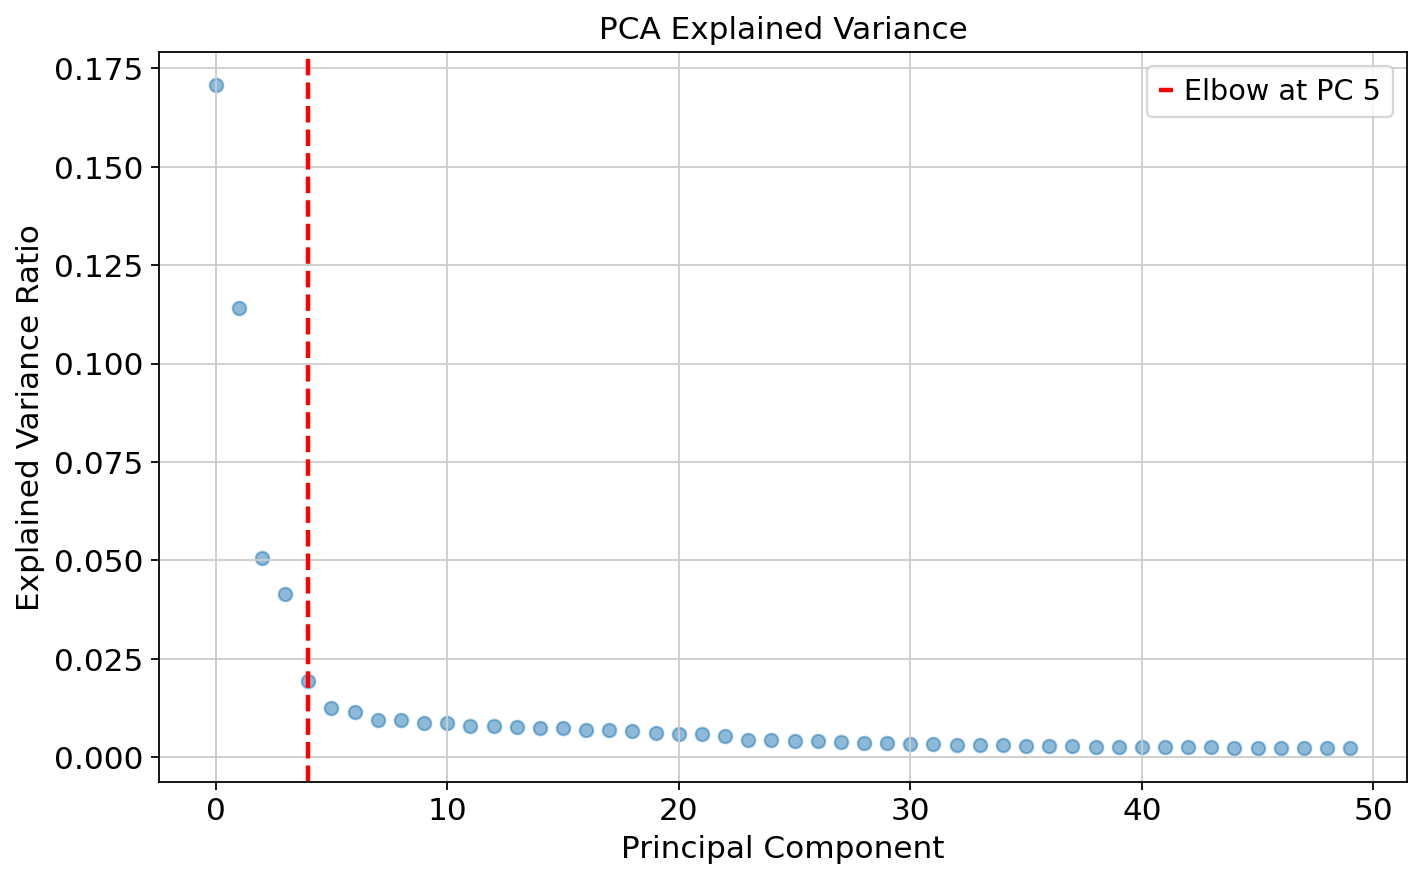

In [54]:
# Implement your solution here (plotting)
plt.figure(figsize=(10, 6))
plt.scatter(np.arange(50), pca.explained_variance_ratio_, alpha=0.5)
plt.axvline(5-1, color='red', linestyle='--', linewidth=2, label='Elbow at PC 5') # Plot a vertical line at the elbow point (PC 5) where the explained variance starts to level off
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance')
plt.legend()
plt.show()

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 5.2</b>
  </div>
  Select the 30 PCs associated with the highest explained variance ratio.
</div>

In [55]:
# Implement your solution here (plotting)
top_30_pcs = pca_result[:, :30] # The result of pca fit_transform is already ordered according to the explained variance, so we can simply take the first 30 columns to get the top 30 principal components
print("The shape of the top 30 principal components is:", top_30_pcs.shape)

The shape of the top 30 principal components is: (4990, 30)


<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(134, 86, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 5.3</b>
  </div>
  Compute the PCA embedding with 30 PCs.
</div>

In [56]:
# Implement your solution here (plotting)
sc.pp.pca(adata, n_comps=30) # Use Scanpy's built-in function to compute the top 30 principal components and store the result in adata.obsm['X_pca']
print("The shape of adata.obsm['X_pca'] is:", adata.obsm['X_pca'].shape)

computing PCA
    with n_comps=30


    finished (0:00:00)
The shape of adata.obsm['X_pca'] is: (4990, 30)


### UMAP

Although PCA reduced our data representation from a 2000-dimensional space into a 30-dimensional space, visualizing data requires a 2D or 3D representation. An ideal compression will retain the global topology and relative distance between clusters - the objective of [Uniform Manifold Approximation and Projection](https://arxiv.org/abs/1802.03426) (UMAP; see [here](https://umap-learn.readthedocs.io/en/latest/how_umap_works.html) for an intuitive and illustrative explanation of the algorithm).

**Three important aspects to keep in mind:**

1. Never rely on 2D/3D representations for quantification! Always validate observations of findinings in higher-dimensional spaces such as the PCA representation or the original GEX space.
2. UMAP embeddings are rotation invariant &rarr; we can always rotate our embedding space to our preferred orientation
3. UMAP preserves the global topology and relative cluster distances &rarr; **ALWAYS** plot UMAP embeddings in square format with the aspect set to "auto" (default in Scanpy)

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 5.4</b>
  </div>
  <ol type="a">
    <li>Use the <i>umap</i> package to compute the 2D UMAP coordinates, based on a 30-nearest neighbor graph and an effective minimum distance between embedded points of 0.5.</li>
    <li>Add the coordinates as columns <code>"umap_1"</code> and <code>"umap_2"</code> to the appropriate DataFrame.</li>
    <li>Visualize the UMAP embedding.</li>
  </ol>
</div>

In [57]:
# Implement your solution here (plotting) (umap coordinates)
import umap

reducer = umap.UMAP(n_neighbors=30, min_dist=0.5, random_state=42) # Initialize UMAP model to compute 2D UMAP coordinates for visualization
umap_result = reducer.fit_transform(top_30_pcs) # Fit the UMAP model on the top 30 principal components and transform to get the 2D UMAP coordinates for each cell
print("The shape of the UMAP result is:", umap_result.shape)

obs_data['UMAP_1'] = umap_result[:, 0] # Add the first UMAP dimension as a column in obs_data for later use
obs_data['UMAP_2'] = umap_result[:, 1] # Add the second UMAP dimension as a column in obs_data for later use
obs_data.head()


/athena/cayuga_0083/scratch/pfw4001/envs/qibs2026-py312/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


The shape of the UMAP result is: (4990, 2)


,total_counts,log1p_total_counts,n_genes_by_counts,log1p_n_genes_by_counts,total_counts_mito,log1p_total_counts_mito,pct_counts_mito,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,UMAP_1,UMAP_2
cell_barcode,,,,,,,,,,,,
AAACCCAGTTGTGCAT-1,874,6.774224,525,6.265301,8,2.197225,0.915332,2,1.098612,0.228833,11.384048,13.033083
AAACGAAAGAACTTCC-1,339,5.828946,46,3.850148,1,0.693147,0.294985,8,2.197225,2.359882,-6.574638,5.155895
AAACGAACAATTGCGT-1,1660,7.415175,837,6.731018,18,2.944439,1.084337,8,2.197225,0.481928,13.276180,10.244841
AAACGAACACCGGAAA-1,124,4.828314,105,4.663439,17,2.890372,13.709677,1,0.693147,0.806452,7.974935,8.626460
AAACGAACAGATTTCG-1,132,4.890349,116,4.762174,7,2.079442,5.303030,0,0.000000,0.000000,7.838102,8.919467


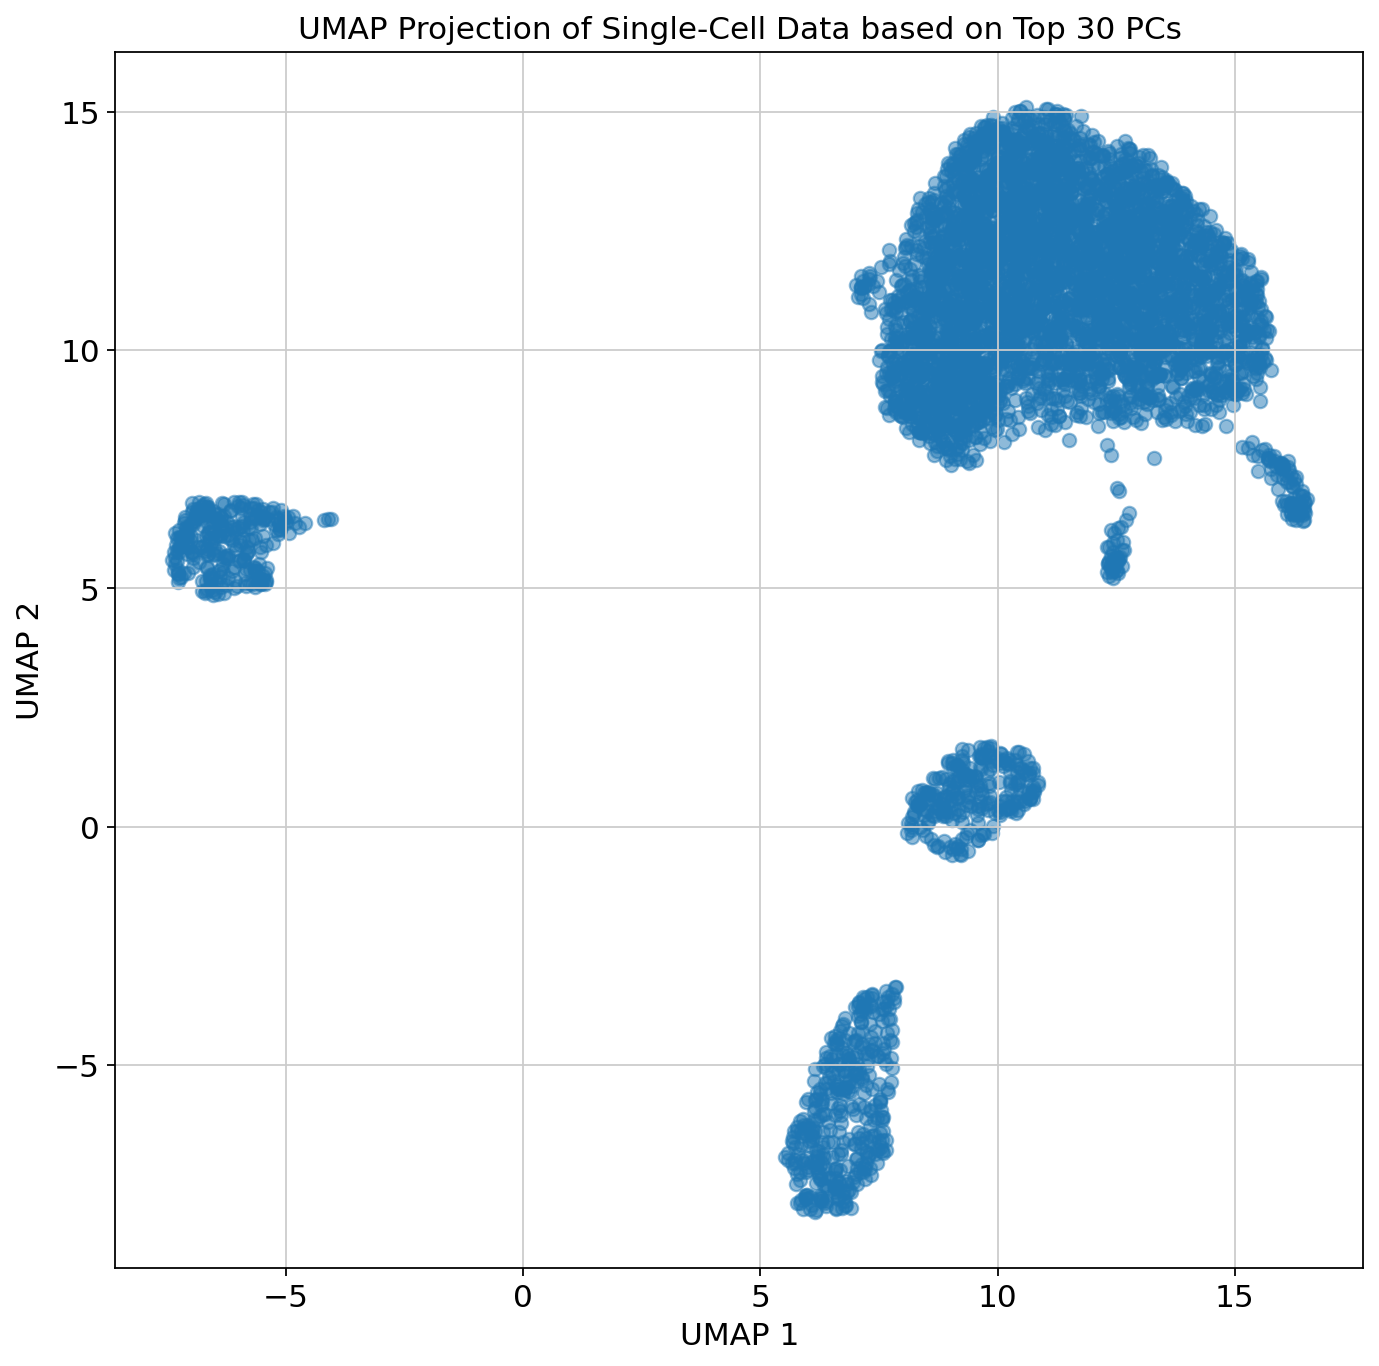

In [58]:
# Implement your solution here (plotting)
fig, ax = plt.subplots(figsize=(10, 10)) # Always plot UMAP embeddings with an equal aspect ratio to avoid distortion of the clusters in the visualization (repreesnt global topolgy and relative cluster distances)
ax.scatter(umap_result[:, 0], umap_result[:, 1], alpha=0.5)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP Projection of Single-Cell Data based on Top 30 PCs')
ax.set_aspect('auto') # Set equal aspect ratio for better visualization of clusters
plt.show()

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(134, 86, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 5.5</b>
  </div>
  <ol type="a">
    <li>Compute a k-nearest neighbor graph with k=30 (UMAP performs this step internally).</li>
    <li>Compute the umap embedding with an effective minimum distance between embedded points of 0.5.</li>
  </ol>
</div>

In [59]:
# Implement your solution here (neighbor graph and umap embedding)
sc.pp.neighbors(adata, n_neighbors=30, knn=True) # Uses X_pca by default; knn=True uses a hard threshold to restrict number of neighbors to parameter
sc.tl.umap(adata, min_dist=0.5, random_state=42) # Compute UMAP embedding using the neighbor graph computed by Scanpy's built-in function and store the result in adata.obsm['X_umap']
print("The shape of adata.obsm['X_umap'] is:", adata.obsm['X_umap'].shape)

computing neighbors
    using 'X_pca' with n_pcs = 30
    finished (0:00:01)
computing UMAP
    finished (0:00:13)
The shape of adata.obsm['X_umap'] is: (4990, 2)


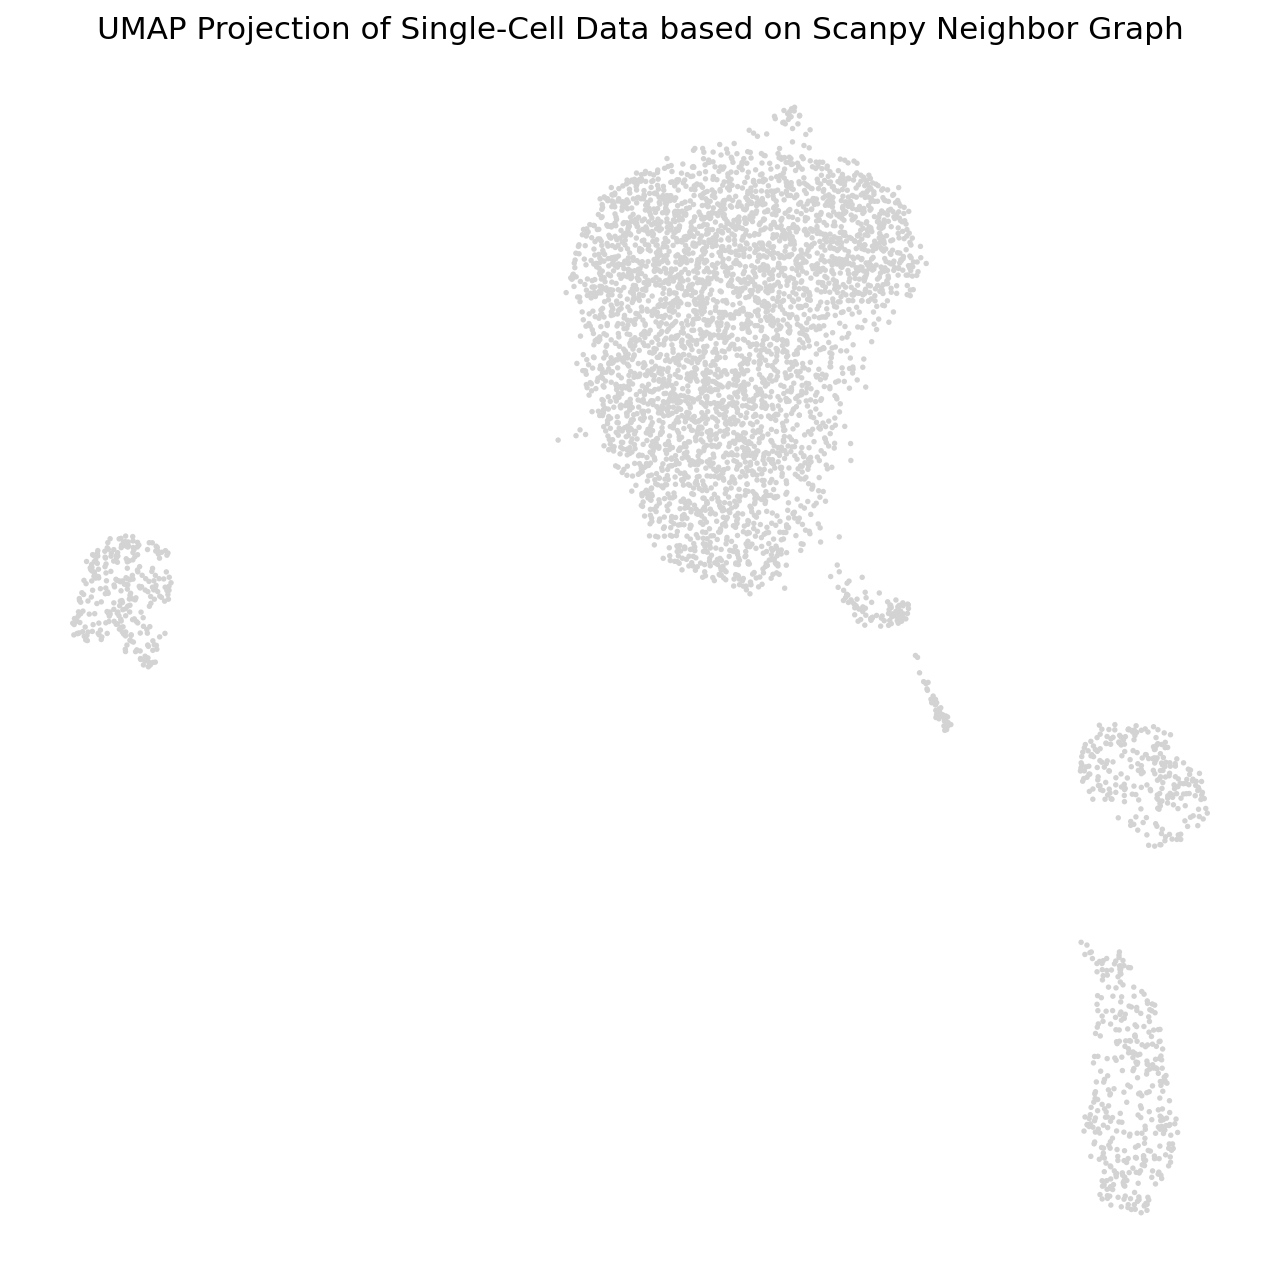

In [60]:
# Implement your solution here (plotting)
fig, ax = plt.subplots(figsize=(10, 10)) # Always plot UMAP embeddings with an equal aspect ratio to avoid distortion of the clusters in the visualization (repreesnt global topolgy and relative cluster distances)
sc.pl.umap(adata, title='UMAP Projection of Single-Cell Data based on Scanpy Neighbor Graph', ax=ax) # Plot the UMAP embedding computed by Scanpy's built-in function
plt.show()

## Cell typing

Havin visualized our data, we observe different clusters which naturally leads us to the question: how can we systematically cluster cells based on their GEX profile, and what do these clusters encode biologically?

Here, we will use the Leiden algorithm to cluster our data: in a first step, the algorithm defines an initial, trivial partioning of a given kNN graph where each node is its own cluster. Following, the algorithm iteratively merges clusters to define partitions by taking into account the number of links between cells in a cluster compared to the overall expected number of links in the dataset.

<img src="https://www.sc-best-practices.org/_images/clustering.jpeg" alt="genescore" width="75%">

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 6.1</b>
  </div>
  <ol type="a">
    <li>Extract the weighted adjacency matrix from <code>adata</code>.</li>
    <li>Using the Python package *igraph* define the corresponding undirected and weighted graph object named <code>graph</code>.</li>
    <li>Compute the leiden clustering of <code>graph</code> based on the modularity objective and at resolution 1.</li>
    <li>Add the leiden cluster assignment as a colum <code>"leiden"</code> to the appropriate DataFrame.</li>
    <li>Plot the UMAP embedding colored by leiden cluster; use <code>vega_20_scanpy</code> for coloring.</li>
  </ol>
</div>

In [61]:
# Implement your solution here (igraph graph definition)
adjacency_matrix = adata.obsp['connectivities'].toarray() # Get the weighted adjacency matrix from the neighbor graph computed by Scanpy's built-in function

import igraph as ig
graph = ig.Graph.Weighted_Adjacency(adjacency_matrix, mode='undirected') # Correct Method is Weighted_Adjacency
graph.summary()

'IGRAPH U-W- 4990 116831 -- \n+ attr: weight (e)'

In [62]:
# Implement your solution here (leiden clustering)
from scanpy._utils.random import set_igraph_random_state  # isort: skip # noqa

# Use the context with set_igraph_random_state(0):`

# to ensure that the Leiden clustering results are reproducible across different runs and environments by setting the random seed for the underlying igraph library used by the leidenalg package
with set_igraph_random_state(0):
    leiden_partition = graph.community_leiden(objective_function='modularity', weights='weight', resolution_parameter=1.0, n_iterations=2) # Perform Leiden clustering on the graph with a resolution parameter of 1.0 to control the granularity of the clusters
    leiden_labels = leiden_partition.membership # Get the cluster labels for each cell from the Leiden partition result

obs_data['leiden'] = leiden_labels # Add the Leiden cluster labels as a column in obs_data for later use

/tmp/ipykernel_618338/4004586225.py:8: DeprecationWarning: resolution_parameter keyword argument is deprecated, use resolution=... instead
  leiden_partition = graph.community_leiden(objective_function='modularity', weights='weight', resolution_parameter=1.0, n_iterations=2) # Perform Leiden clustering on the graph with a resolution parameter of 1.0 to control the granularity of the clusters


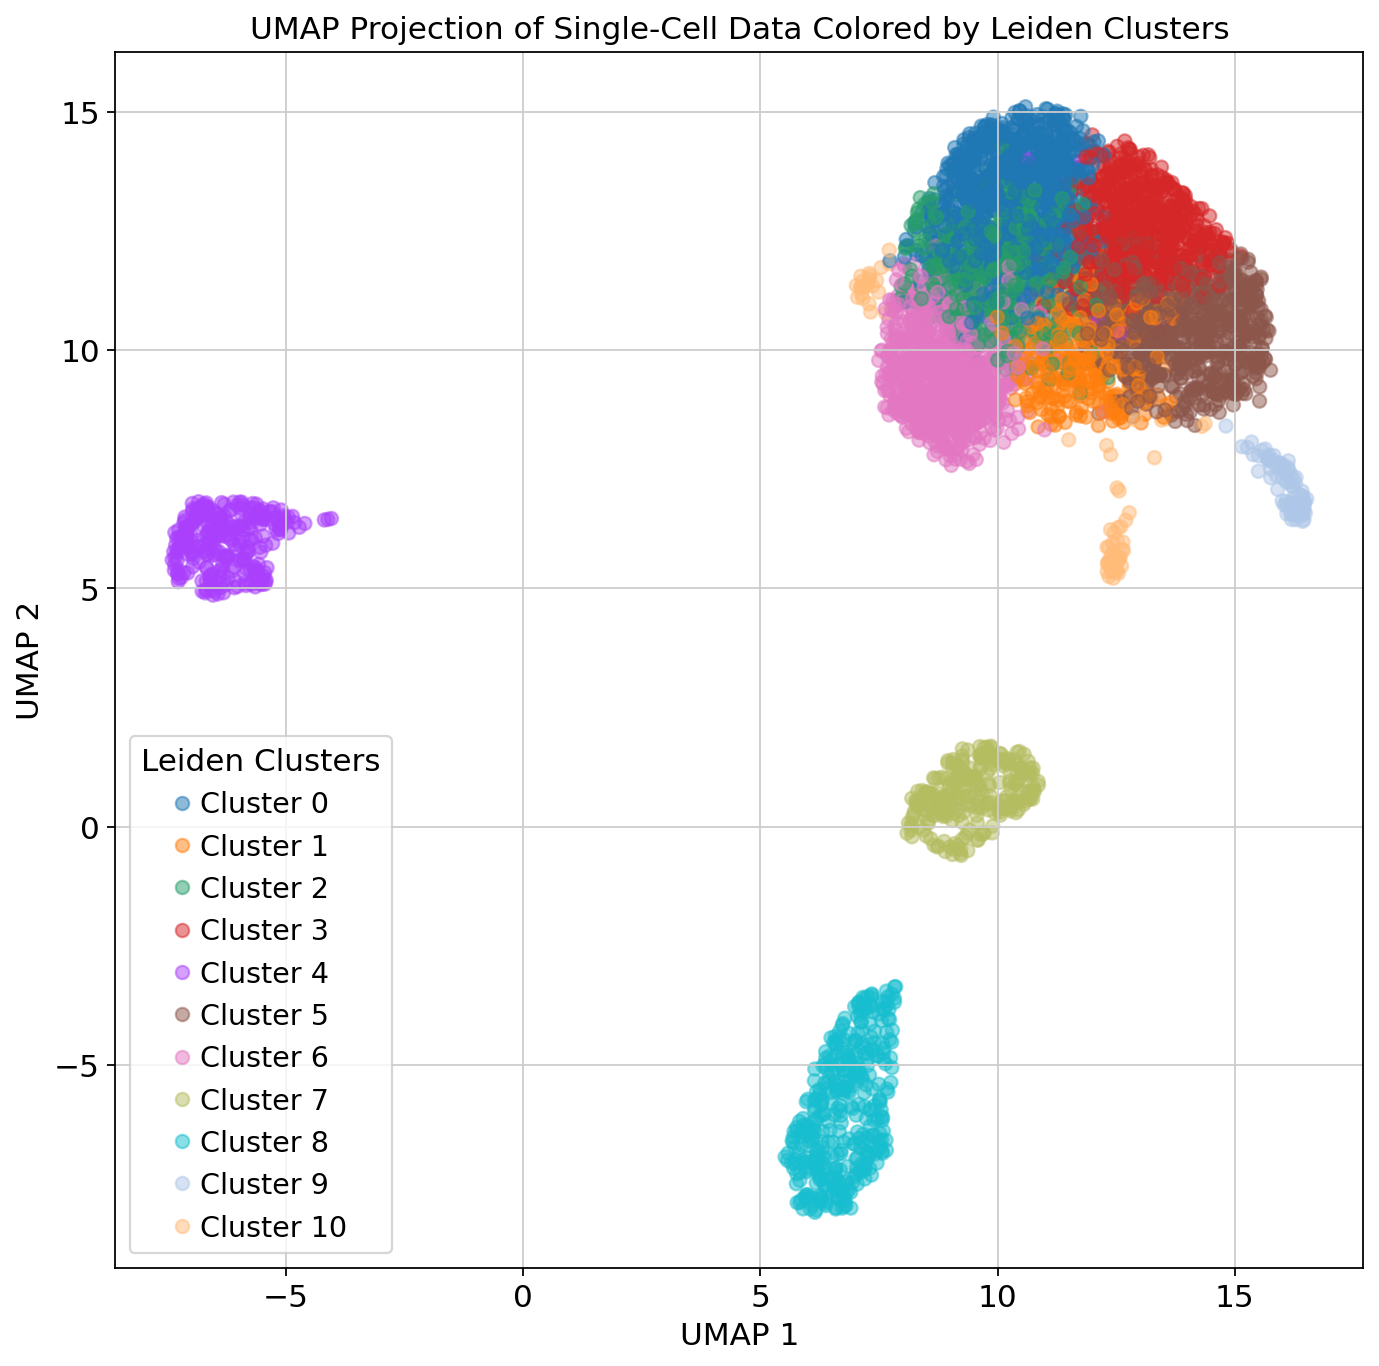

In [63]:
# Implement your solution here (plotting)
from scanpy.plotting.palettes import vega_20_scanpy  # isort: skip # noqa

from matplotlib.colors import ListedColormap
n_clusters = len(set(leiden_labels)) # Get the number of unique clusters identified by Leiden clustering
cmap = ListedColormap(vega_20_scanpy[:n_clusters]) # Create a custom colormap using the first n colors from the vega_20_scanpy palette to ensure that each cluster is colored differently in the UMAP plot

fig, ax = plt.subplots(figsize=(10, 10)) # Always plot UMAP embeddings with an equal aspect ratio to avoid distortion of the clusters in the visualization (repreesnt global topolgy and relative cluster distances)
scatter = ax.scatter(obs_data['UMAP_1'], obs_data['UMAP_2'], c=leiden_labels, cmap=cmap, alpha=0.5) # Plot the UMAP embedding colored by the Leiden cluster labels
ax.legend(handles=scatter.legend_elements()[0], labels=[f'Cluster {i}' for i in range(n_clusters)], title='Leiden Clusters') # Add a legend to indicate which color corresponds to which Leiden cluster
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP Projection of Single-Cell Data Colored by Leiden Clusters')
ax.set_aspect('auto') # Set equal aspect ratio for better visualization of clusters
plt.show()

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(134, 86, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 6.2</b>
  </div>
  Compute the Leiden clustering as before and visualize it in UMAP space.
</div>

running Leiden clustering
    finished (0:00:00)


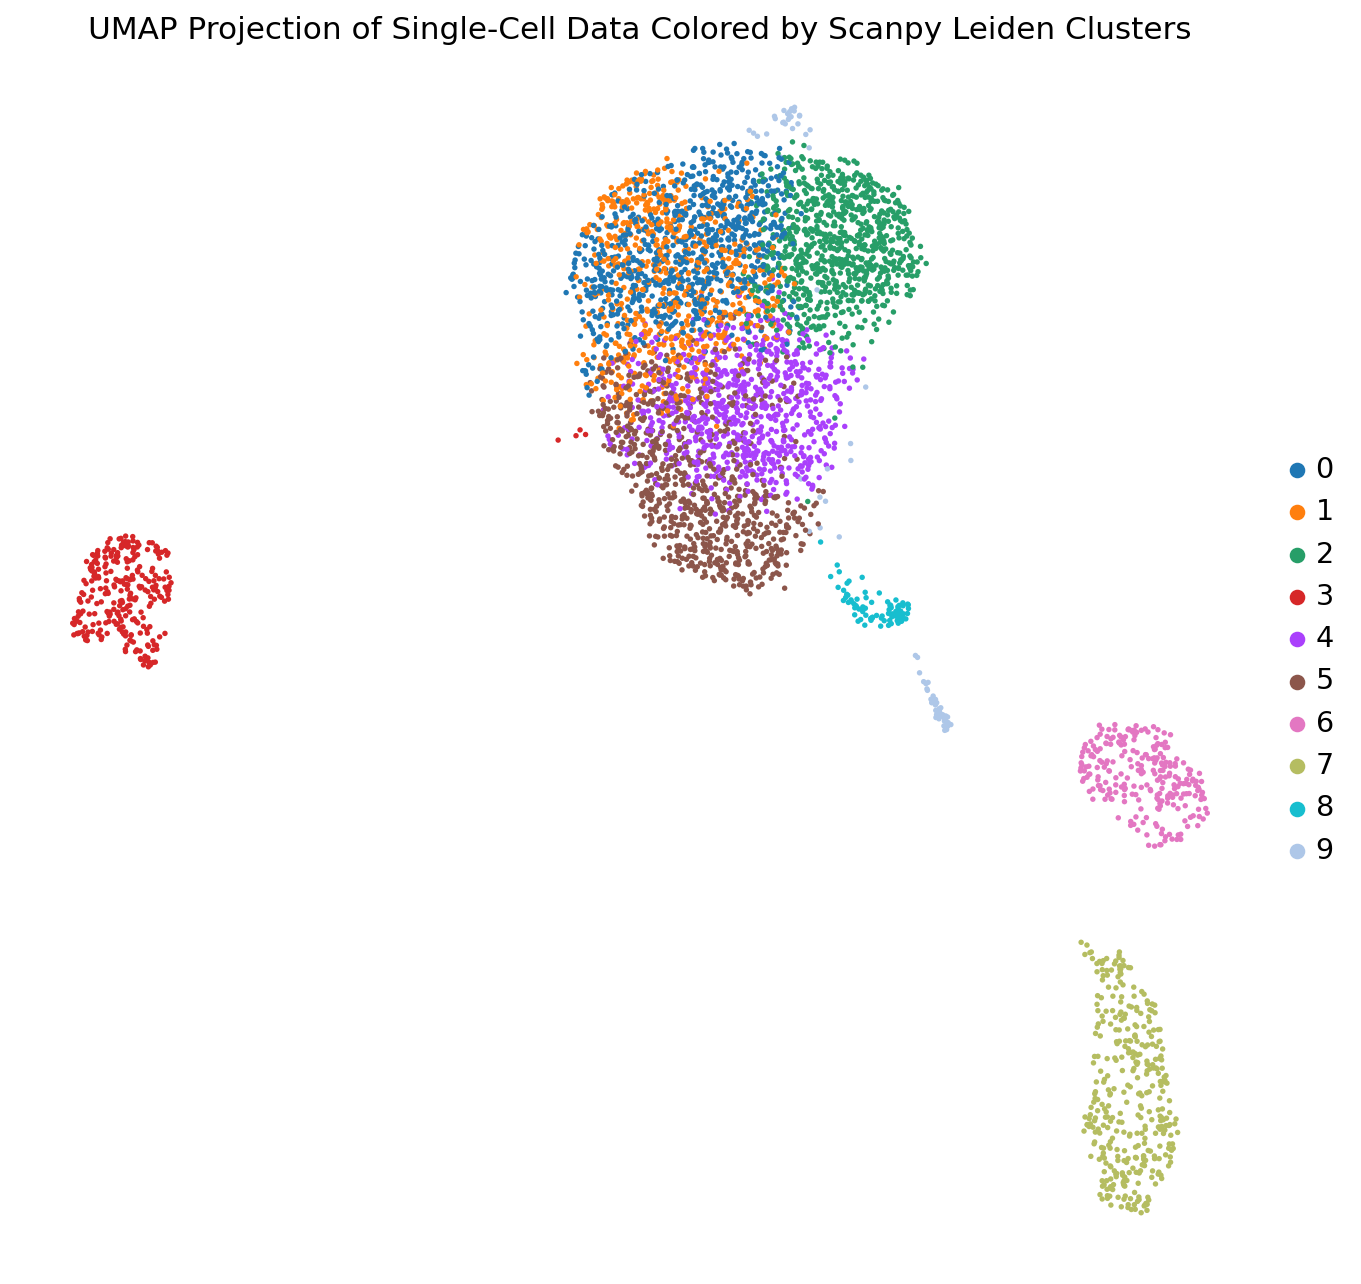

In [64]:
# Implement your solution here (leiden clustering)
sc.tl.leiden(adata, resolution=1.0, random_state=42, flavor='igraph', n_iterations=2) # Use Scanpy's built-in function to perform Leiden clustering on the neighbor graph with a resolution parameter of 1.0 to control the granularity of the clusters and store the cluster labels in adata.obs['leiden']

fig, ax = plt.subplots(figsize=(10, 10)) # Always plot UMAP embeddings with an equal aspect ratio to avoid distortion of the clusters in the visualization (repreesnt global topolgy and relative cluster distances)
sc.pl.umap(adata, color='leiden', cmap=cmap, title='UMAP Projection of Single-Cell Data Colored by Scanpy Leiden Clusters', ax=ax) # Plot the UMAP embedding colored by the Leiden cluster labels computed by Scanpy's built-in function
plt.show()

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 6.3</b>
  </div>
  To ensure reproducibility, update the leiden cluster annotation with <code>DATA_DIR / DATASET_ID / "results" / "leiden.parquet"</code>
</div>

In [65]:
# Implement your solution here (leiden clustering)
reprodudible_leiden_labels = pd.read_parquet(f"{DATA_DIR}/{DATASET_ID}/results/leiden.parquet") # Load the Leiden cluster labels that were computed in a previous run and saved as a parquet file to ensure reproducibility of the clustering results across different runs and environments

# In counts object
obs_data['leiden'] = reprodudible_leiden_labels.reindex(obs_data.index)['leiden'] # Add the reproducible Leiden cluster labels as a column in obs_data for later use

# in adata object
adata.obs['leiden'] = reprodudible_leiden_labels.reindex(adata.obs_names)['leiden'] # Add the reproducible Leiden cluster labels as a column in adata.obs for later use

Finally, to associate the identified clusters with biology, we identify genes differentially expressed in each cluster compared to the rest of the data, ultimatly allowing us to assign cell type labels to these clusters, for example, by studying the expression of known markers in across the clusters.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 6.4</b>
  </div>
  <ol type="a">
    <li>Use a t-test to identify differentially expressed genes in leiden cluster 1 compared to all other cells. Assume that the variance between the two groups differs.</li>
    <li>Adjust the p-values using Benjamini-Hochberg.</li>
  </ol>
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 6.1</b>
  </div>
  <ol>
    <li>How many genes are significantly enriched in leiden cluster 1 at a false discover rate of 0.05?</li>
    <li>Which are the three most differentially enriched genes?</li>
  </ol>
</div>

In [67]:
# Implement your solution here
from scipy import stats
from statsmodels.stats.multitest import multipletests

# Create mask for leiden cluster 1
cluster_1_mask = obs_data['leiden'].astype(int) == 1 # Convert Pandas Series to int values to create a boolean mask for cells in Leiden cluster 1
cluster_1_log1p_normalized_counts = log1p_normalized_counts_per_cell[cluster_1_mask.values, :] # Subset the log1p normalized counts per cell to get only the cells in Leiden cluster 1
other_log1p_normalized_counts = log1p_normalized_counts_per_cell[~cluster_1_mask.values, :] # Subset the log1p normalized counts per cell to get only the cells in other clusters
print("Shape of log1p normalized counts for cluster 1:", cluster_1_log1p_normalized_counts.shape, "Shape of log1p normalized counts for other clusters:", other_log1p_normalized_counts.shape)

# Run Welch's test that assumes unequal variance for each gene and independent samples
t_stats, p_values = stats.ttest_ind(cluster_1_log1p_normalized_counts.toarray(), other_log1p_normalized_counts.toarray(), axis=0, equal_var=False) # Perform Welch's t-test for each gene to compare the mean expression between cluster 1 and the other clusters, converting sparse matrices to dense arrays for the t-test computatation
print("Shape of t-statistics:", t_stats.shape, "Shape of p-values:", p_values.shape)

Shape of log1p normalized counts for cluster 1: (279, 2000) Shape of log1p normalized counts for other clusters: (4711, 2000)
Shape of t-statistics: (2000,) Shape of p-values: (2000,)


In [68]:
# Implement your solution here
# Compute Benjamini-Hochberg correction for multiple testing
reject, p_values_adj, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh') # Perform Benjamini-Hochberg correction for multiple testing to control the false discovery rate at 0.05

In [69]:
print("Number of significantly differentially expressed genes after Benjamini-Hochberg correction:", (~reject).sum())

# Most differentially enriched genes
top_genes_idx = np.argsort(p_values_adj)[:3] # Get the indices of the top 3 most differentially expressed genes based on the adjusted p-values
top_genes = var_data.index.values[top_genes_idx] # Get the gene names of the top 3 most differentially expressed genes using the indices
print("The top 3 most differentially expressed genes in Leiden cluster 1 compared to other clusters are:")
print(top_genes)

Number of significantly differentially expressed genes after Benjamini-Hochberg correction: 342
The top 3 most differentially expressed genes in Leiden cluster 1 compared to other clusters are:
['HBA2' 'HBB' 'HBA1']


<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(134, 86, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 6.5</b>
  </div>
  Compute DEGs for all groups and print the results (gene names, scores, log fold changes, p values, and adjusted p values) for group 1 as a pandas DataFrame.
</div>

In [70]:
# Implement your solution here
sc.tl.rank_genes_groups(adata, groupby='leiden', method='t-test', corr_method='benjamini-hochberg') # Use Scanpy's built-in function to perform differential expression analysis using t-test (uses per-gene variance estimated analogous to Welch's t-test) and Benjamini-Hochberg correction for multiple testing, comparing each Leiden cluster to all other clusters and storing the results in adata.uns['rank_genes_groups']

de_results = adata.uns['rank_genes_groups'] # Get the differential expression results from adata.uns

de_df_cluster_1 = pd.DataFrame({
    'gene': de_results['names']['1'], # Get the gene names for cluster 1
    'score': de_results['scores']['1'], # Get the test statistics for cluster 1
    'log2_fold_change': de_results['logfoldchanges']['1'], # Get the log2 fold changes for cluster 1
    'p_values': de_results['pvals']['1'], # Get the p-values for cluster 1
    'p_value_adj': de_results['pvals_adj']['1'], # Get the adjusted p-values for cluster 1
})

print(de_df_cluster_1.head())

ranking genes
    finished (0:00:01)
    gene       score  log2_fold_change       p_values    p_value_adj
0   HBA2  194.986832         13.587193  9.159261e-304  4.650157e-300
1    HBB  137.544083         13.163776  4.006268e-260  5.547225e-257
2   HBA1  112.725296         13.731324  1.505346e-234  1.146396e-231
3  UBA52   10.069689          2.332975   1.359908e-20   5.234459e-20
4  RPS12    9.920125          2.190808   3.548281e-20   1.340706e-19


`scanpy.pl.rank_genes_groups_dotplot` enables studying the expression of a set of given genes in the indentified Leiden cluster systematically: for each gene, the dot size indicates how many cells in a given group express a given gene, and the color of the dot encodes the group-specific mean expression. Here, we can see that cells in cluster 1 are likely Eryhtrocytes, and cells in cluster 7 T cells, for example.

    using 'X_pca' with n_pcs = 30
Storing dendrogram info using `.uns['dendrogram_leiden']`
categories: 0, 1, 2, etc.
var_group_labels: T, B, Neutrophil, etc.


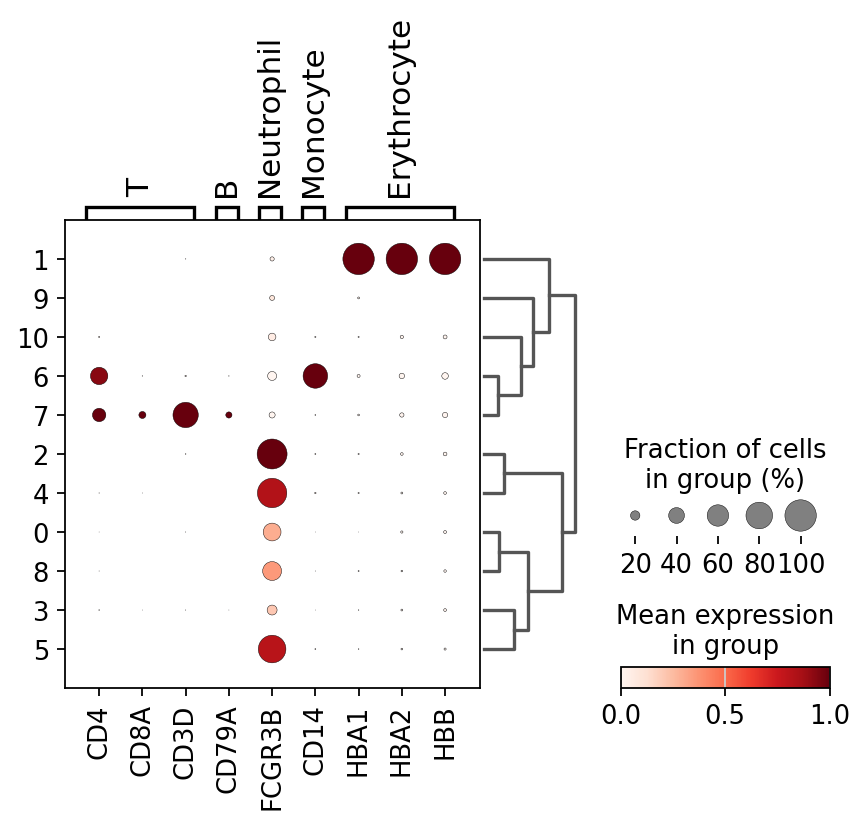

In [71]:
# Uncomment to visualize the GEX using the dotplot
sc.pl.rank_genes_groups_dotplot(
     adata,
     var_names={
         "T": ["CD4", "CD8A", "CD3D"],
         "B": ["CD79A"],
         "Neutrophil": ["FCGR3B"],
         "Monocyte": ["CD14"],
         "Erythrocyte": ["HBA1", "HBA2", "HBB"],
     },
     standard_scale="var",
)